# The transfer story, in the order it happened

Experiments were run sequentially, each batch chosen because of what the
previous one showed. That is the right way to run a screen and it is why the
evaluation grid is not a rectangle: the first block is exhaustive because
nothing was known yet, and everything after it is sparse because it followed
leads.

Sections 1–4 stay inside the exhaustive block: **every architecture at every
reduced action space that has been evaluated, one run each, no gate and no
target-grid training** — sixteen by six, 96 runs, as of this execution. Every
cell exists, so every mean, every marginal and every paired
contrast in this notebook is balanced by construction. Nothing here can be an
artifact of one arm having been given more attempts than another.

Three questions get an answer from that block alone:

1. **How large should the reduced action space be?**
2. **Does physical input scaling (`NLS`) help over the raw inputs (`NL`)?**
3. **Which architectures actually transfer?**

and section 4 puts all three into a single picture.

The later sections then follow the actual experimental sequence: heuristic
gating, target-grid fine-tuning, the complete mk64 transfer-versus-scratch
control, and finally the new 32-evaluation conservative mk32 block. Each
section states which contrasts are complete and which remain conditional.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd()))
import wcci_transfer_data as W

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

data = W.load()
runs = data.runs
DN_HARD, DN_OVERALL = data.dn_hard, data.dn_overall
N_HARD, N_EASY = data.n_hard, data.n_easy
EXPORT_DIR = data.export_dir / "transfer_story"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    fig.savefig(EXPORT_DIR / f"{stem}.png", dpi=170, bbox_inches="tight")


# The complete original block: zero-shot, ungated, every architecture at every cap.
# Later Gmax-delta evaluations share the same short variant labels, so the exact
# campaign prefixes are required to keep this factorial at one run per cell.
ORIGINAL_ZERO_SHOT_GROUP = r"^(?:NL_cas_hl_shared|NLS_cas_hl_izar_shared)_wcci36_mk"
grid = runs.loc[
    (runs["route"] == "bus14 zero-shot")
    & (runs["gate"] == "ungated")
    & runs["group"].str.match(ORIGINAL_ZERO_SHOT_GROUP, na=False)
].copy()
VARIANTS = sorted(grid["variant"].unique())
# Derived from the runs, not hard-coded: a newly evaluated cap joins the grid on
# its own the next time this notebook is executed. The difficult/easy cohort
# split needs the per-episode artifact, so the caps this notebook can *score*
# are only those whose episode CSVs are on disk; ALL_CAPS keeps the rest visible.
ALL_CAPS = W.caps_in(grid)
CAPS = W.caps_in(grid.dropna(subset=["hard_pct"]))
UNSCORED_CAPS = [c for c in ALL_CAPS if c not in CAPS]

scored_grid = grid.loc[grid["mk"].isin(CAPS)]
HARD = scored_grid.pivot_table(index="variant", columns="mk", values="hard_pct")
CAPTURE = scored_grid.pivot_table(index="variant", columns="mk", values="capture_hard_pct")
ORDER = HARD.mean(axis=1).sort_values(ascending=False).index.tolist()
HARD, CAPTURE = HARD.loc[ORDER], CAPTURE.loc[ORDER]
ALIVE = [v for v in ORDER if HARD.loc[v].max() >= 0.5]

assert len(grid) == len(VARIANTS) * len(ALL_CAPS), "the ungated block is no longer a full factorial"
if UNSCORED_CAPS:
    missing_groups = sorted(grid.loc[grid["mk"].isin(UNSCORED_CAPS), "group"].unique())
    display(Markdown(
        "⚠️ **"
        + ", ".join(f"mk{c}" for c in UNSCORED_CAPS)
        + f"** {'is' if len(UNSCORED_CAPS) == 1 else 'are'} evaluated but cannot be scored on "
        "the difficult cohort: the result JSONs are on disk but the per-episode artifacts "
        "they point at are not. Sections 1-4 therefore run on "
        + ", ".join(f"mk{c}" for c in CAPS)
        + f", and the {'cap' if len(UNSCORED_CAPS) == 1 else 'caps'} above appear only in the "
        "`overall_pct` view at the end of section 4. To fold them in everywhere, sync:\n\n"
        + "\n".join(f"    outputs/full_test_eval_actions/shared/{g}" for g in missing_groups)
    ))
display(Markdown(
    f"**{len(grid)} evaluations = {len(VARIANTS)} architectures x {len(ALL_CAPS)} action caps, "
    f"one per cell**, of which {len(scored_grid)} carry difficult-cohort metrics.  \n"
    f"Metric: survival on the **{N_HARD} difficult chronics** — the ones do-nothing loses. "
    f"Do-nothing scores **{DN_HARD:.2f}%** there; the {N_EASY} easy chronics are excluded "
    f"because nothing can be won on them.  \n"
    f"**{len(ALIVE)} of {len(VARIANTS)}** architectures beat 0.5% somewhere on the grid; "
    f"the other {len(VARIANTS) - len(ALIVE)} lose the grid within a handful of steps at "
    f"every cap."
))

**96 evaluations = 16 architectures x 6 action caps, one per cell**, of which 96 carry difficult-cohort metrics.  
Metric: survival on the **24 difficult chronics** — the ones do-nothing loses. Do-nothing scores **8.34%** there; the 26 easy chronics are excluded because nothing can be won on them.  
**12 of 16** architectures beat 0.5% somewhere on the grid; the other 4 lose the grid within a handful of steps at every cap.

## 0. How the runs actually happened, and why the grid has holes

Four batches, each one launched because of what the previous one showed.

In [2]:
timeline = (
    runs.assign(block=np.select(
        [
            runs["route"] != "bus14 zero-shot",
            runs["gate"] == "gated",
        ],
        ["3-4. target-grid training", "2. gated screen"],
        default="1. zero-shot sweep",
    ))
    .groupby(["block", "route", "gate"], observed=True)
    .agg(evaluations=("key", "size"), architectures=("variant", "nunique"),
         caps=("mk", lambda s: ", ".join(f"mk{int(m)}" for m in sorted(set(s.dropna())))))
    .reset_index()
)
display(Markdown(f"""
| when | batch | what it was | why it looks like this |
|---|---|---|---|
| **15-16 Aug** | zero-shot sweep | 16 architectures x 6 caps, ungated | Nothing was known, so it was run exhaustively. **This is the block this notebook uses.** |
| **16-17 Aug** | local-rho gated screen | 38 evaluations on 8 of the 16 architectures, mk64/128/256 only | Launched *because* the sweep showed most architectures collapsing ungated. Only the checkpoints that looked salvageable were gated, and the promising ones got all four thresholds. |
| **16-18 Aug** | fine-tuning | mk256 aggressive, then mk64 conservative, 2 and 5 architectures | Launched on the architectures the first two blocks selected. |
| **18 Aug** | BC on greedy labels | 1 architecture at mk64 | On the single cell that looked most promising. |
| **20 Aug** | conservative fine-tune + from-scratch control | all 8 `NLS` architectures at mk64, gated and ungated | Deliberately complete this time, so the two arms can be compared cell by cell. **This is the block section 9 uses.** |
| **22 Aug** | conservative fine-tune at mk32 | all 8 `NLS` architectures, best-test and final checkpoints, ungated and local-rho 0.95 | Tests whether the action-space result from block 1 carries into target-grid adaptation. **Section 10 keeps all 32 evaluations distinct.** |

Each block is a rational response to the one before it, and the cost is that
**only the first block is a factorial.** Every later block is a conditional
sample: it contains the architectures that had already done well, evaluated
more thoroughly than the ones that had not. A maximum or a mean taken across
those blocks measures how many attempts each arm was given.

The plot below is the same coverage map as in `wcci_four_questions.ipynb`,
repeated here because it is the premise of everything that follows.
"""))
display(timeline)


| when | batch | what it was | why it looks like this |
|---|---|---|---|
| **15-16 Aug** | zero-shot sweep | 16 architectures x 6 caps, ungated | Nothing was known, so it was run exhaustively. **This is the block this notebook uses.** |
| **16-17 Aug** | local-rho gated screen | 38 evaluations on 8 of the 16 architectures, mk64/128/256 only | Launched *because* the sweep showed most architectures collapsing ungated. Only the checkpoints that looked salvageable were gated, and the promising ones got all four thresholds. |
| **16-18 Aug** | fine-tuning | mk256 aggressive, then mk64 conservative, 2 and 5 architectures | Launched on the architectures the first two blocks selected. |
| **18 Aug** | BC on greedy labels | 1 architecture at mk64 | On the single cell that looked most promising. |
| **20 Aug** | conservative fine-tune + from-scratch control | all 8 `NLS` architectures at mk64, gated and ungated | Deliberately complete this time, so the two arms can be compared cell by cell. **This is the block section 9 uses.** |
| **22 Aug** | conservative fine-tune at mk32 | all 8 `NLS` architectures, best-test and final checkpoints, ungated and local-rho 0.95 | Tests whether the action-space result from block 1 carries into target-grid adaptation. **Section 10 keeps all 32 evaluations distinct.** |

Each block is a rational response to the one before it, and the cost is that
**only the first block is a factorial.** Every later block is a conditional
sample: it contains the architectures that had already done well, evaluated
more thoroughly than the ones that had not. A maximum or a mean taken across
those blocks measures how many attempts each arm was given.

The plot below is the same coverage map as in `wcci_four_questions.ipynb`,
repeated here because it is the premise of everything that follows.


,block,route,gate,evaluations,architectures,caps
0,1. zero-shot sweep,bus14 zero-shot,ungated,156,16,"mk32, mk64, mk128, mk256, mk512, mk1024"
1,2. gated screen,bus14 zero-shot,gated,146,16,"mk32, mk64, mk128, mk256"
2,3-4. target-grid training,bus14 zero-shot + AIB,gated,60,15,"mk32, mk64, mk128, mk256"
3,3-4. target-grid training,bus14 zero-shot + AIB,ungated,60,15,"mk32, mk64, mk128, mk256"
4,3-4. target-grid training,MAPPO fine-tune (aggressive),gated,8,2,mk256
5,3-4. target-grid training,MAPPO fine-tune (conservative),gated,40,16,"mk32, mk64"
6,3-4. target-grid training,MAPPO fine-tune (conservative),ungated,40,16,"mk32, mk64"
7,3-4. target-grid training,BC on greedy labels,gated,1,1,mk64
8,3-4. target-grid training,BC on greedy labels,ungated,1,1,mk64
9,3-4. target-grid training,MAPPO scratch,gated,8,8,mk64


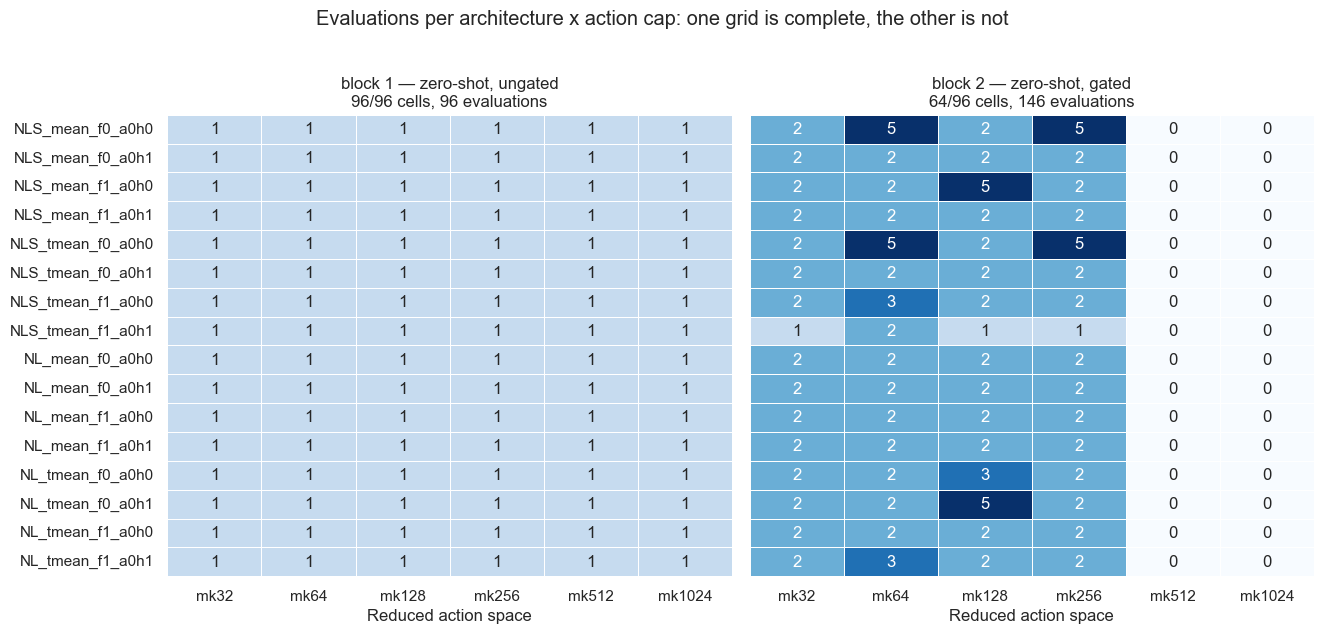

In [3]:
def coverage(frame):
    return (
        frame.pivot_table(index="variant", columns="mk", values="key",
                          aggfunc="size", fill_value=0, observed=True)
        .reindex(index=VARIANTS, columns=CAPS, fill_value=0)
    )


zero_all = runs.loc[runs["route"] == "bus14 zero-shot"]
cover_ungated = coverage(grid)
cover_gated = coverage(zero_all.loc[zero_all["gate"] == "gated"])

fig, axes = plt.subplots(1, 2, figsize=(13.4, 6.2), sharey=True)
for ax, cover, title in (
    (axes[0], cover_ungated, "block 1 — zero-shot, ungated"),
    (axes[1], cover_gated, "block 2 — zero-shot, gated"),
):
    sns.heatmap(cover, annot=True, fmt="d", cmap="Blues", vmin=0, vmax=4,
                linewidths=0.6, linecolor="white", cbar=False, ax=ax)
    filled = int((cover.to_numpy() > 0).sum())
    ax.set(xlabel="Reduced action space", ylabel="",
           title=f"{title}\n{filled}/{cover.size} cells, "
                 f"{int(cover.to_numpy().sum())} evaluations")
    ax.set_xticklabels([f"mk{c}" for c in CAPS])
fig.suptitle("Evaluations per architecture x action cap: one grid is complete, the other is not",
             y=1.02)
fig.tight_layout()
save_figure(fig, "00_coverage")
plt.show()

## 1. The reduced action space: smaller wins

`k` caps how many topology actions each agent may choose from — the size of the
candidate set distilled from the teacher dataset. Every architecture was
evaluated at all five, so this contrast is paired inside each architecture: the
lines below are the same sixteen models, moved along the x-axis and nothing
else.

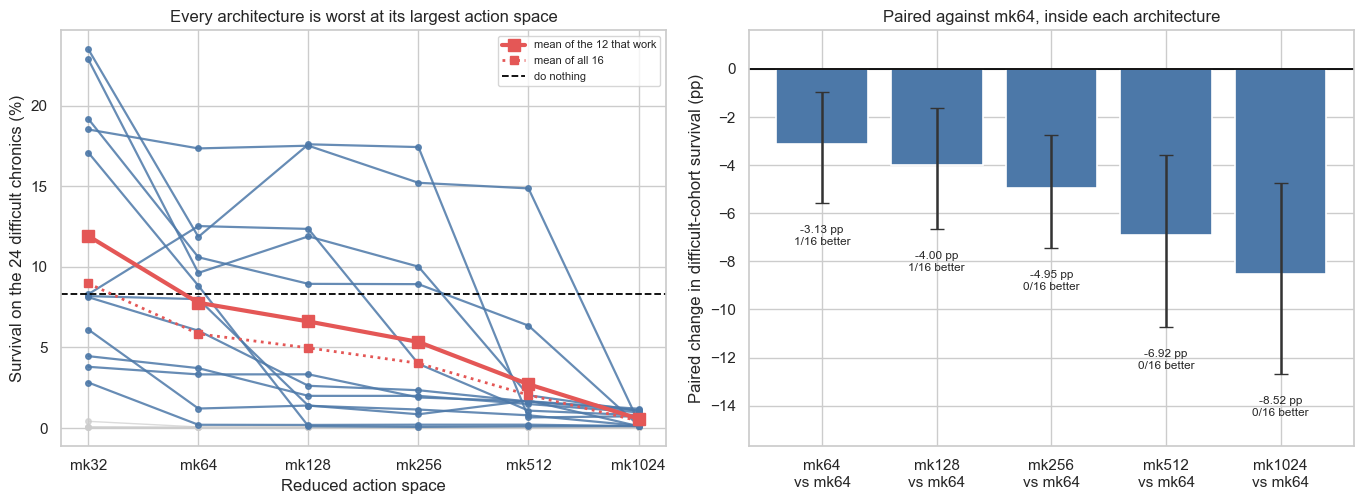

,mk,mean,lo,hi,better
0,64,-3.13,-5.57,-0.95,1
1,128,-4.00,-6.66,-1.62,1
2,256,-4.95,-7.44,-2.77,0
3,512,-6.92,-10.73,-3.59,0
4,1024,-8.52,-12.68,-4.72,0


#### Everything degrades together as the candidate set grows

,hard_mean,hard_mean_alive,hard_best,collapsed,easy_kept_mean,overall_mean
mk,,,,,,
32,8.97,11.91,23.50,4,14.38,34.66
64,5.85,7.77,17.35,5,10.50,25.33
128,4.97,6.61,17.60,6,7.69,19.85
256,4.02,5.34,17.43,6,6.38,16.95
512,2.05,2.72,14.87,6,4.75,13.17
1024,0.45,0.58,1.20,10,1.00,3.24


The ceiling moves with `k` too — the greedy oracle climbs from **67.9%** at mk64 to **94.9%** at mk256 — so raw survival could in principle be falling only because the target got harder to reach. It is not. `capture`, which puts do-nothing at 0 and that oracle at 100 at **each cap separately**, falls the same way over the architectures that work: **14.4%** -> **-0.9%** -> **-2.9%** -> **-3.5%** -> **-8.2%** -> **-9.5%** from mk64 to mk1024.

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.2))

for variant in ORDER:
    alive = variant in ALIVE
    axes[0].plot(CAPS, HARD.loc[variant], marker="o", markersize=4,
                 linewidth=1.6 if alive else 1.0,
                 color="#4C78A8" if alive else "#CCCCCC",
                 alpha=0.85 if alive else 0.7, zorder=2 if alive else 1)
axes[0].plot(CAPS, HARD.loc[ALIVE].mean(), marker="s", markersize=8, linewidth=3.0,
             color="#E45756", zorder=3, label=f"mean of the {len(ALIVE)} that work")
axes[0].plot(CAPS, HARD.mean(), marker="s", markersize=6, linewidth=2.0,
             color="#E45756", linestyle=":", zorder=3, label="mean of all 16")
axes[0].axhline(DN_HARD, color="black", linestyle="--", linewidth=1.3, label="do nothing")
axes[0].set(ylabel=f"Survival on the {N_HARD} difficult chronics (%)",
            title="Every architecture is worst at its largest action space")
axes[0].legend(fontsize=8, loc="upper right")

deltas = HARD.sub(HARD[CAPS[0]], axis=0)
stats = []
for cap in CAPS[1:]:
    mean_d, lo, hi = W.paired_bootstrap(deltas[cap])
    stats.append({"mk": cap, "mean": mean_d, "lo": lo, "hi": hi,
                  "better": int((deltas[cap] > 0).sum())})
stats = pd.DataFrame(stats)
positions = np.arange(len(stats))
axes[1].bar(positions, stats["mean"], color="#4C78A8", edgecolor="white", linewidth=1.2)
axes[1].errorbar(positions, stats["mean"], yerr=[stats["mean"] - stats["lo"],
                                                 stats["hi"] - stats["mean"]],
                 fmt="none", ecolor="#333333", capsize=5, linewidth=1.8)
for x, row in zip(positions, stats.itertuples()):
    axes[1].annotate(f"{row.mean:+.2f} pp\n{row.better}/16 better", (x, row.lo),
                     xytext=(0, -30), textcoords="offset points", ha="center", fontsize=8.5)
axes[1].axhline(0, color="black", linewidth=1.3)
axes[1].set_xticks(positions, [f"mk{c}\nvs mk64" for c in stats["mk"]])
axes[1].set(ylabel="Paired change in difficult-cohort survival (pp)",
            title="Paired against mk64, inside each architecture")
axes[1].set_ylim(stats["lo"].min() - 3.0, max(stats["hi"].max(), 1) + 0.6)

for ax in (axes[0],):
    ax.set_xscale("log", base=2)
    ax.set_xticks(CAPS, [f"mk{c}" for c in CAPS])
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_xlabel("Reduced action space")
fig.tight_layout()
save_figure(fig, "01_action_space")
plt.show()

display(stats.round(2))
display(Markdown("#### Everything degrades together as the candidate set grows"))
display(
    grid.groupby("mk").agg(
        hard_mean=("hard_pct", "mean"),
        hard_mean_alive=("hard_pct", lambda s: grid.loc[s.index].query("variant in @ALIVE")["hard_pct"].mean()),
        hard_best=("hard_pct", "max"),
        collapsed=("collapsed", "sum"),
        easy_kept_mean=("easy_kept", "mean"),
        overall_mean=("overall_pct", "mean"),
    )
)
display(Markdown(
    f"The ceiling moves with `k` too — the greedy oracle climbs from "
    f"**{data.greedy_hard[64]:.1f}%** at mk64 to **{data.greedy_hard[256]:.1f}%** at mk256 — "
    f"so raw survival could in principle be falling only because the target got harder to "
    f"reach. It is not. `capture`, which puts do-nothing at 0 and that oracle at 100 at "
    f"**each cap separately**, falls the same way over the architectures that work: "
    + " -> ".join(f"**{CAPTURE.loc[ALIVE, c].mean():.1f}%**" for c in CAPS)
    + " from mk64 to mk1024."
))

### What this says

**Use the smallest cap you have — mk32, and the trend has not turned over yet.**
Fifteen of the sixteen architectures score their best at mk32 and the sixteenth
at mk64; not one peaks above that. Paired inside each architecture against mk32,
every larger cap is a clear loss whose interval excludes zero: mk64 −3.13 pp
(CI [−5.57, −0.95]), mk128 −4.00, mk256 −4.95, mk512 −6.92, mk1024 −8.52.

The degradation is not subtle and it is not a scoring artifact. From mk32 to
mk1024 the number of architectures that collapse outright rises from 4 to 10 of
16, the average number of *easy* chronics still carried to the end falls from
14.4 to 1.0 of 26, and headroom capture — which renormalises against the oracle
at each cap — falls monotonically as well.

Two things make mk32 more than just the next point on a line. It is the only cap
whose **grid mean clears the do-nothing floor** (8.97 % against 8.34 %), and the
only one whose mean capture over the working architectures is **positive**
(+14.4 %, against −1.0 % at mk64 and worse above). At every other cap the average
transferred policy is a liability; at mk32 it is not.

The mechanism is the obvious one. A larger candidate set does contain better
actions: the oracle proves it, climbing to 94.9% of the difficult cohort at
mk256 while offering only 33.1% at mk32. But the transferred scorer has to rank
all of them from one forward pass, on a grid whose action semantics it has never
seen, and its discrimination does not scale with the set. The extra candidates
are noise it has to reject, and it does not reject them — so it does better with
a smaller ceiling it can actually reach than a larger one it cannot.

**A small distilled action set is not a compromise here — it is the setting that
makes transfer work at all.** mk32 is the smallest cap evaluated and it is the
best one; nothing in this grid says the optimum has been passed, so mk16 and mk8
are worth running before concluding otherwise.

## 2. Physical scaling: no effect on average, a large one in interaction

`NL` feeds the encoder raw power channels and the absolute voltage angle. `NLS`
divides the power channels by each grid's own maximum generator rating and
replaces the absolute angle with the drop along each line. It is a property of
the source training run, so the two halves of the grid are otherwise identical:
eight architecture cells x five caps, run in both conditions, forty matched
pairs.

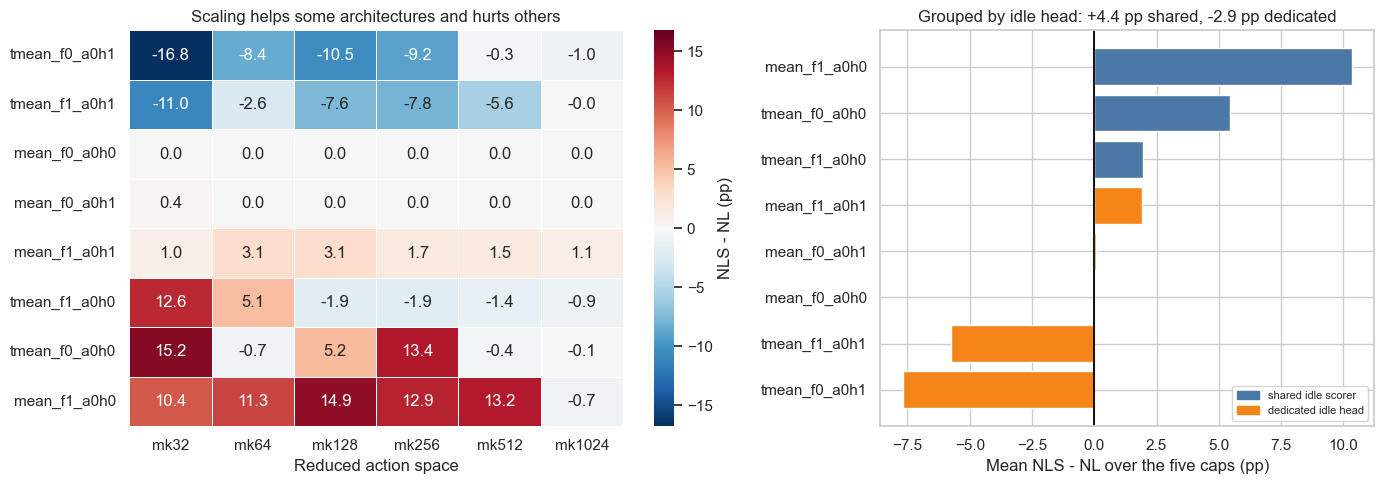

Over all **48** matched pairs, physical scaling is worth **+0.79 pp**, bootstrap CI **[-1.13, +2.74]** — an interval that contains zero. It wins **28** pairs and loses **20**, which is a coin flip.

,runs,mean,best,sd,collapsed
scaling,,,,,
physical scaling,48,4.78,23.50,6.86,19
raw inputs,48,3.99,22.86,5.35,18


#### The same 40 pairs, split by the idle head

,pairs,mean_pp,wins
idle,,,
dedicated idle head,24,-2.86,12
shared idle scorer,24,4.44,16


In [5]:
pairs = W.matched_pairs(grid, "scaling", ("raw inputs", "physical scaling"),
                        ["pool", "features", "head", "mk"])
mean_s, lo_s, hi_s = W.paired_bootstrap(pairs["delta"])
pairs["cell"] = (pairs["pool"] + "_f" + pairs["features"].astype(str)
                 + "_a0h" + pairs["head"].astype(str))
matrix = pairs.pivot_table(index="cell", columns="mk", values="delta")
matrix = matrix.loc[matrix.mean(axis=1).sort_values().index]

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.0),
                         gridspec_kw={"width_ratios": [1.25, 1]})
limit = np.abs(matrix.to_numpy()).max()
sns.heatmap(matrix, annot=True, fmt=".1f", cmap="RdBu_r", center=0,
            vmin=-limit, vmax=limit, linewidths=0.6, linecolor="white",
            cbar_kws={"label": "NLS - NL (pp)"}, ax=axes[0])
axes[0].set(xlabel="Reduced action space", ylabel="",
            title="Scaling helps some architectures and hurts others")
axes[0].set_xticklabels([f"mk{c}" for c in CAPS])

by_head = matrix.mean(axis=1).rename("mean_delta").reset_index()
by_head["idle"] = np.where(by_head["cell"].str.endswith("a0h0"),
                           "shared idle scorer", "dedicated idle head")
colours = {"shared idle scorer": "#4C78A8", "dedicated idle head": "#F58518"}
axes[1].barh(by_head["cell"], by_head["mean_delta"],
             color=[colours[i] for i in by_head["idle"]], edgecolor="white", linewidth=1.0)
axes[1].axvline(0, color="black", linewidth=1.3)
shared = by_head.loc[by_head["idle"] == "shared idle scorer", "mean_delta"].mean()
dedicated = by_head.loc[by_head["idle"] == "dedicated idle head", "mean_delta"].mean()
axes[1].set(xlabel="Mean NLS - NL over the five caps (pp)", ylabel="",
            title=f"Grouped by idle head: {shared:+.1f} pp shared, {dedicated:+.1f} pp dedicated")
axes[1].legend(handles=[Patch(color=c, label=k) for k, c in colours.items()],
               fontsize=8, loc="lower right")
fig.tight_layout()
save_figure(fig, "02_scaling")
plt.show()

display(Markdown(
    f"Over all **{len(pairs)}** matched pairs, physical scaling is worth "
    f"**{mean_s:+.2f} pp**, bootstrap CI **[{lo_s:+.2f}, {hi_s:+.2f}]** — an interval that "
    f"contains zero. It wins **{int((pairs['delta'] > 0).sum())}** pairs and loses "
    f"**{int((pairs['delta'] < 0).sum())}**, which is a coin flip."
))
display(
    grid.groupby("scaling").agg(
        runs=("key", "size"), mean=("hard_pct", "mean"), best=("hard_pct", "max"),
        sd=("hard_pct", "std"), collapsed=("collapsed", "sum"),
    )
)
display(Markdown("#### The same 40 pairs, split by the idle head"))
display(
    pairs.assign(idle=np.where(pairs["head"] == 0, "shared idle scorer", "dedicated idle head"))
    .groupby("idle").agg(pairs=("delta", "size"), mean_pp=("delta", "mean"),
                         wins=("delta", lambda s: int((s > 0).sum())))
)

### What this says

**On its own, scaling does nothing measurable** — `+0.79 pp` over forty-eight
pairs with an interval spanning zero, 28 wins to 20 losses. If the question is
"does the correction help", the honest answer from the complete grid is that
this experiment cannot tell.

**But the average is hiding a large and structured spread.** The eight cells
range from **+10.3 pp** to **−5.9 pp**, and the heat map shows those signs are
stable across caps rather than flipping cell by cell — the same cell is red or
blue at mk64, mk128, mk256 and mk512, and everything washes out at mk1024 where
every model is dead anyway. That is not the pattern of noise.

Grouped by the idle head, the split is **+4.4 pp** for the shared scorer against
**−2.9 pp** for the dedicated head. It is not a clean partition — `mean_f1_a0h1`
is dedicated and still gains +1.9 pp — but the two large negatives are both
`tmean_*_a0h1`, and the two large positives are both `*_a0h0`:

* `mean_f1_a0h0` **+10.3 pp** — this is what makes it the best model on the grid;
* `tmean_f0_a0h0` **+5.5 pp**;
* `tmean_f0_a0h1` **−7.7 pp** and `tmean_f1_a0h1` **−5.8 pp**;
* the two `mean_f0` cells: essentially 0.0, because those models are dead in both
  conditions and nothing can move them.

A reading that fits, offered as a hypothesis and not a result: with a shared
scorer, do-nothing competes against real actions through the same pathway, so
the scale of the input features sets how often anything at all beats it, and
correcting that scale on a new grid matters. With a dedicated head, that
decision is made by separate parameters the correction does not touch, and the
rescaling only perturbs the ranking among the actions. Eight cells at one seed
cannot test that; what they do establish is that **the correct answer to "should
we use physical scaling" is architecture-dependent, so the grid average is the
wrong summary to quote either way.**

The other visible thing is dispersion. `NLS` has the best run on the grid
(23.5%, against 22.9% for `NL`) and the same floor, with a standard deviation
about a quarter larger. It raises the ceiling without raising the floor.

## 3. Which architectures actually transfer

Sixteen models, each averaged over its five caps. The question is not which
scores highest — one seed cannot settle that — but whether the ordering has
structure, and it does.

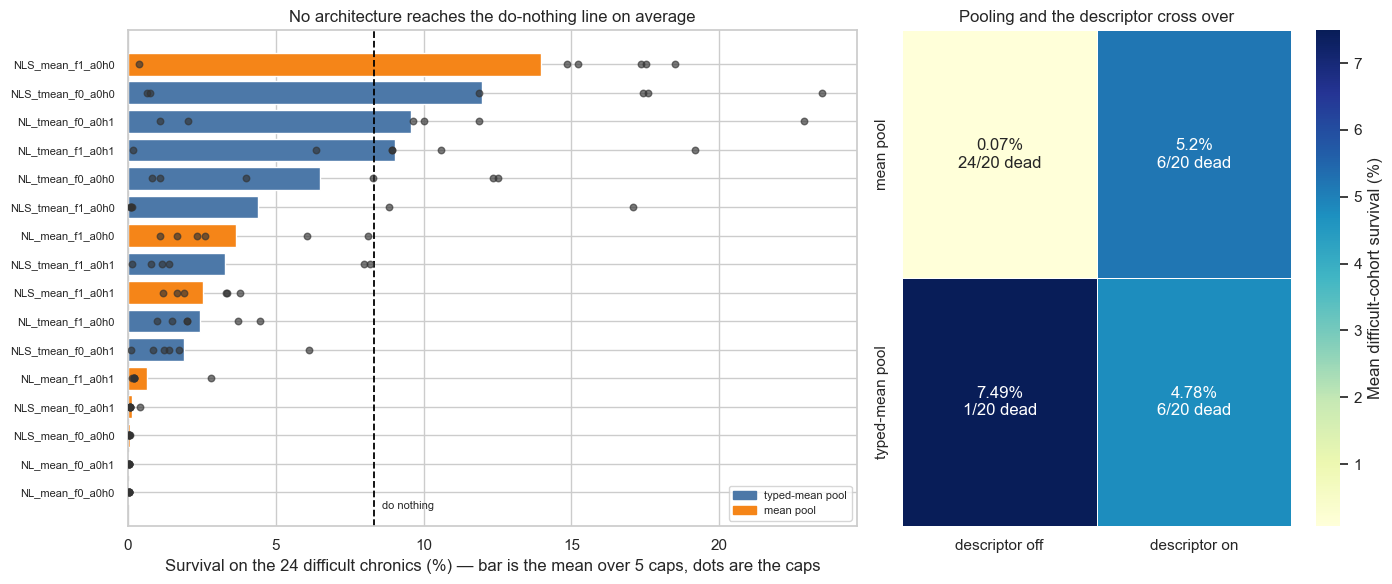

,variant,scaling,pooling,descriptor,idle,hard_mean,hard_best,collapsed,easy_kept
2,NLS_mean_f1_a0h0,physical scaling,mean pool,descriptor on,shared idle scorer,13.98,18.52,1,19.83
4,NLS_tmean_f0_a0h0,physical scaling,typed-mean pool,descriptor off,shared idle scorer,11.96,23.50,0,19.67
13,NL_tmean_f0_a0h1,raw inputs,typed-mean pool,descriptor off,dedicated idle head,9.58,22.86,0,21.83
15,NL_tmean_f1_a0h1,raw inputs,typed-mean pool,descriptor on,dedicated idle head,9.03,19.18,1,12.50
12,NL_tmean_f0_a0h0,raw inputs,typed-mean pool,descriptor off,shared idle scorer,6.51,12.53,0,10.00
6,NLS_tmean_f1_a0h0,physical scaling,typed-mean pool,descriptor on,shared idle scorer,4.39,17.09,4,7.50
10,NL_mean_f1_a0h0,raw inputs,mean pool,descriptor on,shared idle scorer,3.64,8.12,0,7.00
7,NLS_tmean_f1_a0h1,physical scaling,typed-mean pool,descriptor on,dedicated idle head,3.28,8.19,1,15.17
3,NLS_mean_f1_a0h1,physical scaling,mean pool,descriptor on,dedicated idle head,2.54,3.80,0,0.00
14,NL_tmean_f1_a0h0,raw inputs,typed-mean pool,descriptor on,shared idle scorer,2.44,4.46,0,0.00


In [6]:
ranking = (
    grid.groupby(["variant", "scaling", "pooling", "descriptor", "idle"],
                 as_index=False, observed=True)
    .agg(hard_mean=("hard_pct", "mean"), hard_best=("hard_pct", "max"),
         collapsed=("collapsed", "sum"), easy_kept=("easy_kept", "mean"))
    .sort_values("hard_mean")
)
POOL_COLORS = {"typed-mean pool": "#4C78A8", "mean pool": "#F58518"}

fig, axes = plt.subplots(1, 2, figsize=(14.2, 6.0),
                         gridspec_kw={"width_ratios": [1.5, 1]})
positions = np.arange(len(ranking))
axes[0].barh(positions, ranking["hard_mean"],
             color=[POOL_COLORS[p] for p in ranking["pooling"]],
             edgecolor="white", linewidth=1.0)
for y, variant in zip(positions, ranking["variant"]):
    axes[0].scatter(HARD.loc[variant], [y] * len(CAPS), s=22, color="#333333",
                    alpha=0.65, zorder=3)
axes[0].axvline(DN_HARD, color="black", linestyle="--", linewidth=1.3)
axes[0].text(DN_HARD + 0.25, -0.6, "do nothing", fontsize=8)
axes[0].set_yticks(positions, ranking["variant"], fontsize=8)
axes[0].set(xlabel=f"Survival on the {N_HARD} difficult chronics (%) — bar is the mean over "
                   f"5 caps, dots are the caps",
            title="No architecture reaches the do-nothing line on average")
axes[0].legend(handles=[Patch(color=c, label=k) for k, c in POOL_COLORS.items()],
               fontsize=8, loc="lower right")

cells = grid.pivot_table(index="pooling", columns="descriptor", values="hard_pct",
                         aggfunc="mean", observed=True)
collapses = grid.pivot_table(index="pooling", columns="descriptor", values="collapsed",
                             aggfunc="sum", observed=True)
labels = (cells.round(2).astype(str) + "%\n" + collapses.astype(str) + "/20 dead")
sns.heatmap(cells, annot=labels.to_numpy(), fmt="", cmap="YlGnBu", linewidths=0.6,
            linecolor="white", cbar_kws={"label": "Mean difficult-cohort survival (%)"},
            ax=axes[1])
axes[1].set(xlabel="", ylabel="", title="Pooling and the descriptor cross over")
fig.tight_layout()
save_figure(fig, "03_architectures")
plt.show()

display(ranking.sort_values("hard_mean", ascending=False))

### What this says

**Read the bottom of the ranking first.** Two architectures score 0.05% at every
single cap and two more never clear 0.5%: they lose the grid within a handful of
steps, always. All four are `mean` pooling with the descriptor **off** — and the
heat map shows that cell is 24 of 24 dead, mean survival 0.07%, with almost none
of the 26 easy chronics kept. That is not underperformance, it is a policy that actively
destroys a grid do-nothing would have carried to the end.

The mechanism is legible. With a joint mean over the touched-node embeddings and
no static action descriptor, two candidate actions that touch the same nodes
produce the *same vector*. The scorer has nothing to rank. Give it either fix —
per-type pooling, or the descriptor — and it recovers.

The two fixes are alternatives, not additions. Typed-mean **without** the
descriptor is the strongest cell on the grid (7.49%, 1 of 24 dead); adding the
descriptor on top makes it *worse* (4.78%, 6 of 24 dead). Mean pooling with the
descriptor lands in between (5.20%, 6 of 24). Whatever the scorer
needs to tell candidates apart, per-type pooling supplies it better, and
supplying it twice interferes.

**The top of the ranking is two models, and they are not the same recipe:**

* `NLS_mean_f1_a0h0` — 13.98% mean, the most consistent model across caps, and
  the one section 2's interaction is really about: mean pooling rescued by the
  descriptor, plus scaling, plus the shared idle scorer.
* `NLS_tmean_f0_a0h0` — 11.96% mean and the single highest score anywhere on the
  grid (**23.50% at mk32**): the clean recipe, per-type pooling with nothing
  bolted on.

Both are `NLS` and both are `a0h0`. Every architecture in the top five uses the
shared idle scorer or typed-mean pooling or both.

**And the honest headline: only two architectures average above the do-nothing
floor.** The best mean on the grid is 13.98% against a floor of 8.34%, and that
is a mean over caps that includes mk1024 where it collapses. Twelve of sixteen
architectures sit below the floor on average. Ungated zero-shot transfer, taken
as a whole, is still not a working system — which is why the next block of
experiments was a gate.

## 4. All three answers in one picture

The grid is small enough to show whole. Rows are architectures ordered by mean,
columns are action caps, colour is difficult-cohort survival. The bar above each
column is the cap's mean and the bar beside each row is the architecture's mean;
the strip on the left marks the input condition.

Everything in the three sections above is visible in it: the columns fade to the
right (§1), the left strip alternates without an obvious pattern until you look
at the top four rows (§2), and the rows split into a live upper half and a dead
lower half (§3).

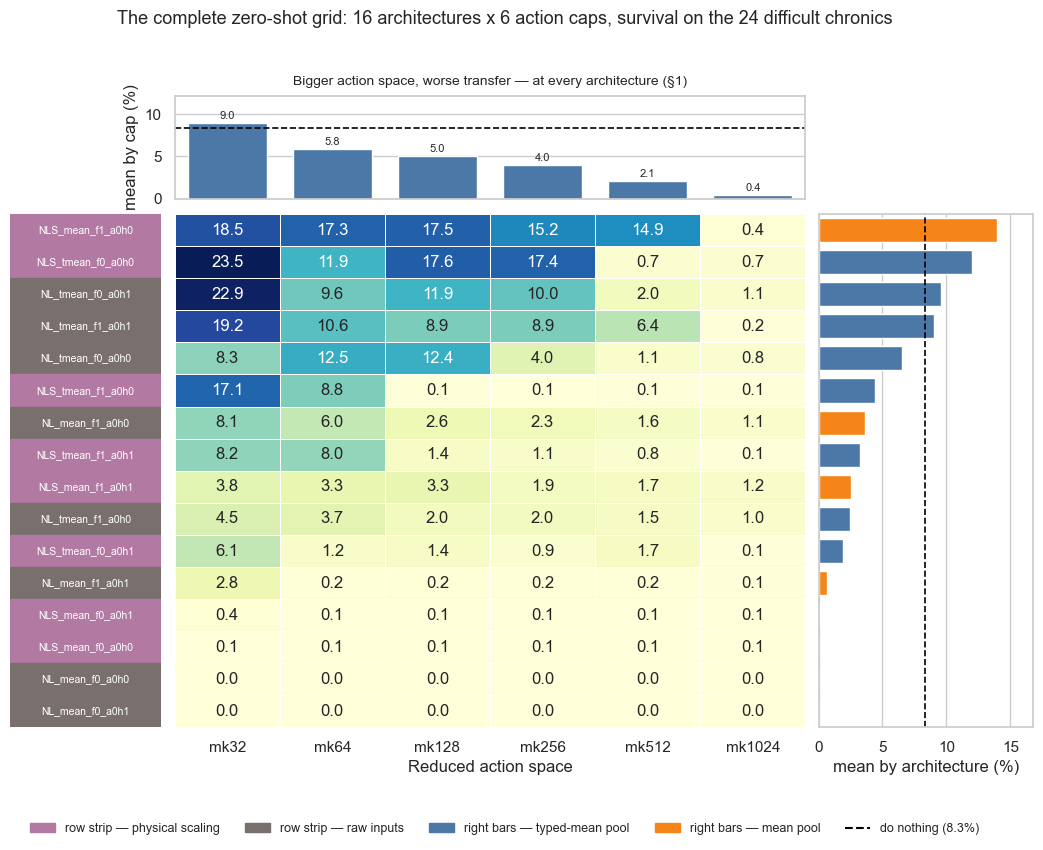

In [7]:
fig = plt.figure(figsize=(13.2, 8.2))
gs = fig.add_gridspec(2, 3, width_ratios=[0.24, 1, 0.34], height_ratios=[0.20, 1],
                      wspace=0.04, hspace=0.05)
ax_strip = fig.add_subplot(gs[1, 0])
ax_main = fig.add_subplot(gs[1, 1])
ax_right = fig.add_subplot(gs[1, 2])
ax_top = fig.add_subplot(gs[0, 1])

sns.heatmap(HARD, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.7, linecolor="white",
            cbar=False, ax=ax_main, vmin=0, vmax=HARD.to_numpy().max())
ax_main.set(xlabel="Reduced action space", ylabel="")
ax_main.set_xticklabels([f"mk{c}" for c in CAPS])
ax_main.set_yticklabels([])

SCALE_COLORS = {"NLS": "#B279A2", "NL": "#79706E"}  # distinct from the pooling palette
for y, variant in enumerate(ORDER):
    family = "NLS" if variant.startswith("NLS") else "NL"
    ax_strip.add_patch(plt.Rectangle((0, y), 1, 1, color=SCALE_COLORS[family]))
    ax_strip.text(0.5, y + 0.5, variant, ha="center", va="center",
                  fontsize=7.5, color="white")
ax_strip.set(xlim=(0, 1), ylim=(len(ORDER), 0), xticks=[], yticks=[])
ax_strip.grid(False)
for spine in ax_strip.spines.values():
    spine.set_visible(False)

ax_top.bar(np.arange(len(CAPS)) + 0.5, HARD.mean(), width=0.75, color="#4C78A8",
           edgecolor="white", linewidth=1.0)
for x, value in enumerate(HARD.mean()):
    ax_top.annotate(f"{value:.1f}", (x + 0.5, value), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=8)
ax_top.axhline(DN_HARD, color="black", linestyle="--", linewidth=1.2)
ax_top.set(xlim=(0, len(CAPS)), xticks=[], ylabel="mean by cap (%)")
ax_top.set_ylim(0, max(HARD.mean().max(), DN_HARD) * 1.35)
ax_top.set_title("Bigger action space, worse transfer — at every architecture (§1)",
                 fontsize=10, pad=8)

row_means = HARD.mean(axis=1)
pool_of = grid.drop_duplicates("variant").set_index("variant")["pooling"]
ax_right.barh(np.arange(len(ORDER)) + 0.5, row_means,
              color=[POOL_COLORS[pool_of[v]] for v in ORDER],
              edgecolor="white", linewidth=1.0, height=0.75)
ax_right.axvline(DN_HARD, color="black", linestyle="--", linewidth=1.2)
ax_right.set(ylim=(len(ORDER), 0), yticks=[], xlabel="mean by architecture (%)")
ax_right.set_xlim(0, max(row_means.max(), DN_HARD) * 1.2)

handles = (
    [Patch(color=c, label=f"row strip — {W.SCALING_LABELS[k]}") for k, c in SCALE_COLORS.items()]
    + [Patch(color=c, label=f"right bars — {k}") for k, c in POOL_COLORS.items()]
    + [plt.Line2D([], [], color="black", linestyle="--", label=f"do nothing ({DN_HARD:.1f}%)")]
)
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.035), frameon=False)
fig.suptitle(
    f"The complete zero-shot grid: {len(VARIANTS)} architectures x {len(CAPS)} action caps, "
    f"survival on the {N_HARD} difficult chronics",
    y=0.985, fontsize=13,
)
save_figure(fig, "04_summary")
plt.show()

### The whole block in four sentences

1. **The action set should be small, and the optimum is at or below the smallest
   cap tried.** `mk32` is the best cap for **15 of 16** architectures; every
   larger one is a paired loss with an interval clear of zero, from −3.1 pp at
   mk64 to −8.5 pp at mk1024. It is also the only cap whose grid mean beats
   do-nothing and the only one with positive mean capture. mk16 and mk8 are the
   obvious next runs.
2. **Physical scaling is not a main effect** — +0.65 pp over 40 pairs with an
   interval spanning zero — but it is not noise either: it ranges from +10.3 pp
   to −5.9 pp with signs stable across caps, and groups +3.4 vs −2.1 pp by the
   idle head. Quote it per architecture, never as a grid average.
3. **One architectural choice separates working models from destructive ones:**
   the scorer must be able to tell two candidates apart, whether by per-type
   pooling or by the action descriptor. Supply neither and 24 of 24 runs destroy
   the grid; supply both and they interfere.
4. **None of it is enough on its own.** The best architecture averages 13.98%
   against a do-nothing floor of 8.34%, twelve of sixteen sit below that floor,
   and the grid's single best run reaches 23.50%. That is the finding that made
   the next batch a gated screen rather than more architectures.

## 5. Provenance audit: why Section 6.7 cannot yet be plotted against WCCI

The eight source values in thesis Section 6.7 come from the non-shared
checkpoints `best_test_cas_hl_NL_<variant>_s0.tar`, evaluated under
`outputs/full_test_eval/NL_cas_hl`. None of those exact checkpoints has a WCCI
evaluation in the downloaded results.

The WCCI zero-shot block elsewhere in this notebook uses a later campaign whose
checkpoint names contain `_shared`. Those actors were trained separately with a
shared candidate scorer and the restored 13-feature legacy node schema. Their
paired bus14 results live under `outputs/full_test_eval/shared/bus14`; they are
not the Section 6.7 results and cannot be substituted for them.

The table below reads the Section 6.7 values directly from their eight JSON
files and verifies whether the exact checkpoint stem appears in a WCCI result.
A source-to-target plot should only be created once every `WCCI match found`
entry is true.

In [8]:
import json as _json
import re as _re

screen_f_root = data.task_dir / "outputs/full_test_eval/NL_cas_hl"
all_eval_root = data.task_dir / "outputs/full_test_eval"
screen_f_pattern = _re.compile(
    r"best_test_cas_hl_NL_(?P<pool>mean|tmean)_f(?P<descriptor>[01])_a0h(?P<idle>[01])_s0$"
)

def _screen_f_label(pool, descriptor, idle):
    return ", ".join([
        "typed mean" if pool == "tmean" else "mean",
        "descriptor on" if descriptor == "1" else "descriptor off",
        "dedicated idle" if idle == "1" else "shared idle",
    ])

# Index the exact checkpoint stem used by every downloaded WCCI evaluation.
wcci_checkpoint_stems = set()
for result_path in all_eval_root.rglob("*.json"):
    try:
        payload = _json.loads(result_path.read_text(encoding="utf-8"))
    except (OSError, _json.JSONDecodeError):
        continue
    if payload.get("target_env_id") == "bus36_wcci_nomaint":
        wcci_checkpoint_stems.add(Path(str(payload.get("checkpoint", ""))).stem)

rows = []
for result_path in sorted(screen_f_root.glob("*.json")):
    payload = _json.loads(result_path.read_text(encoding="utf-8"))
    checkpoint_stem = Path(str(payload.get("checkpoint", ""))).stem
    match = screen_f_pattern.fullmatch(checkpoint_stem)
    if match is None:
        continue
    rows.append({
        "architecture": _screen_f_label(
            match.group("pool"), match.group("descriptor"), match.group("idle")
        ),
        "checkpoint": checkpoint_stem,
        "bus14_survival_pct": payload.get("survival_percent"),
        "bus14_episodes": payload.get("eval_episodes"),
        "WCCI match found": checkpoint_stem in wcci_checkpoint_stems,
    })

section67_audit = pd.DataFrame(rows).sort_values(
    "bus14_survival_pct", ascending=False
).reset_index(drop=True)
assert len(section67_audit) == 8, f"Expected 8 Section 6.7 checkpoints, found {len(section67_audit)}"
assert not section67_audit["WCCI match found"].any(), (
    "A Section 6.7 WCCI evaluation now exists; replace this audit with a matched plot."
)

display(Markdown(
    f"**Matched source-to-WCCI pairs available: "
    f"{int(section67_audit['WCCI match found'].sum())} / {len(section67_audit)}.**"
))
display(section67_audit.style.format({"bus14_survival_pct": "{:.2f}%"}))

**Matched source-to-WCCI pairs available: 0 / 8.**

,architecture,checkpoint,bus14_survival_pct,bus14_episodes,WCCI match found
0,"mean, descriptor off, dedicated idle",best_test_cas_hl_NL_mean_f0_a0h1_s0,99.52%,201,False
1,"typed mean, descriptor on, shared idle",best_test_cas_hl_NL_tmean_f1_a0h0_s0,99.50%,201,False
2,"mean, descriptor off, shared idle",best_test_cas_hl_NL_mean_f0_a0h0_s0,99.18%,201,False
3,"mean, descriptor on, dedicated idle",best_test_cas_hl_NL_mean_f1_a0h1_s0,98.66%,201,False
4,"mean, descriptor on, shared idle",best_test_cas_hl_NL_mean_f1_a0h0_s0,98.32%,201,False
5,"typed mean, descriptor off, dedicated idle",best_test_cas_hl_NL_tmean_f0_a0h1_s0,98.17%,201,False
6,"typed mean, descriptor off, shared idle",best_test_cas_hl_NL_tmean_f0_a0h0_s0,92.50%,201,False
7,"typed mean, descriptor on, dedicated idle",best_test_cas_hl_NL_tmean_f1_a0h1_s0,57.84%,201,False


### 5.1 Matched transferable checkpoints: does bus14 performance predict WCCI transfer?

The exact Screen F checkpoints in Section 6.7 have not been evaluated on WCCI,
so they cannot support a source-to-target plot yet. A valid comparison is
nevertheless available for the later transferable shared-checkpoint campaign.
For each of its eight architecture variants, the plot pairs the **same saved
checkpoint** evaluated on 201 bus14 test chronics and transferred without
target training to the WCCI test set.

The comparison is split by input condition because the raw-input and
physically scaled actors are separate training runs. WCCI is fixed to the
ungated `mk32` evaluation, and the target metric is survival on the difficult
chronics only. Fixing the action space and excluding the gate prevents those
choices from being mixed with the architecture comparison. The numbers inside
the markers identify the eight candidate-scorer variants using the key below
the plot.

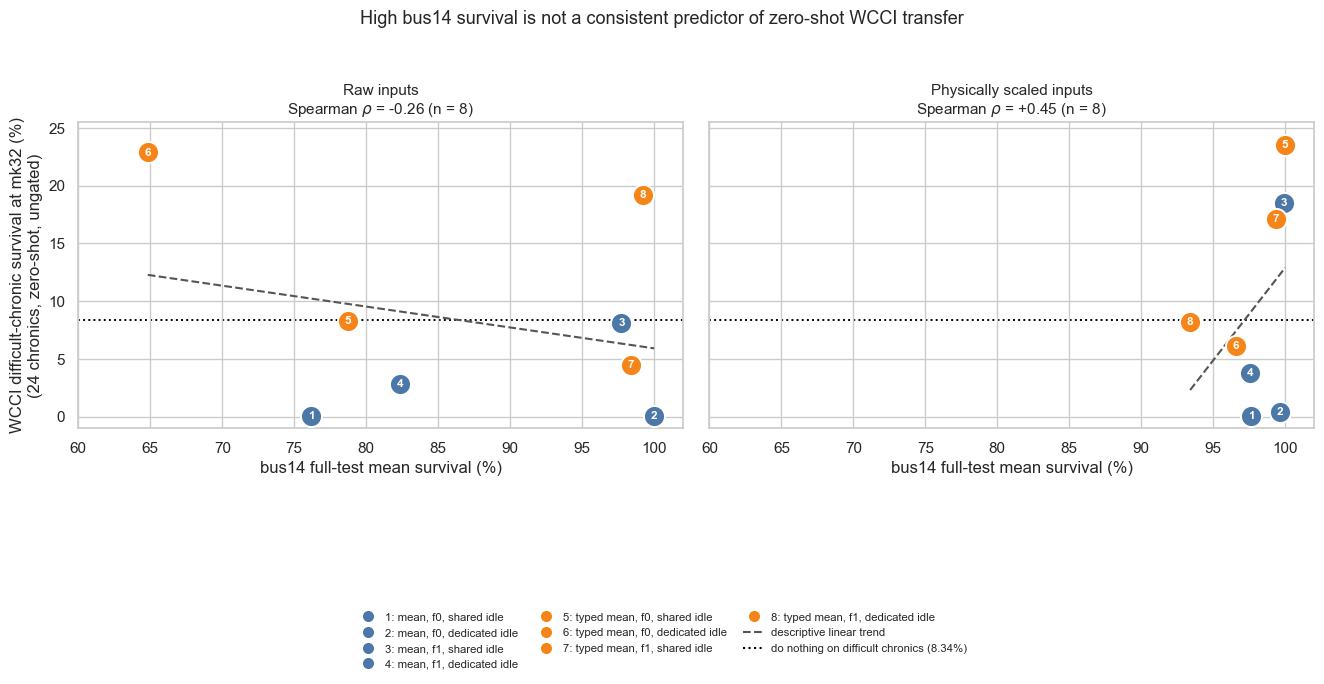

The raw-input checkpoints show a weak negative rank association, while the physically scaled checkpoints show a moderate positive one. The signs disagree, and each panel contains only eight single-seed variants. The defensible conclusion is therefore that **bus14 survival alone does not consistently rank zero-shot WCCI transfer**. Architecture details and input handling matter beyond source-grid score.

,input_condition,n_variants,spearman_rho,spearman_p,pearson_r
0,Raw inputs,8,-0.26,0.53,-0.28
1,Physically scaled inputs,8,0.45,0.26,0.41


,design_id,design,input_condition,bus14_survival_pct,wcci_difficult_survival_pct,wcci_overall_survival_pct,bus14_checkpoint_stem,bus14_episodes,bus14_result_path,episode_csv
0,1,mean_f0_a0h0,physical scaling,97.64,0.08,1.01,best_test_cas_hl_NLS_izar_shared_mean_f0_a0h0_s0,201,/Users/corentinplumet/Documents/RL_Marl2grid/T...,/Users/corentinplumet/Documents/RL_Marl2grid/T...
1,2,mean_f0_a0h1,physical scaling,99.66,0.42,0.52,best_test_cas_hl_NLS_izar_shared_mean_f0_a0h1_s0,201,/Users/corentinplumet/Documents/RL_Marl2grid/T...,/Users/corentinplumet/Documents/RL_Marl2grid/T...
2,3,mean_f1_a0h0,physical scaling,99.94,18.52,60.89,best_test_cas_hl_NLS_izar_shared_mean_f1_a0h0_s0,201,/Users/corentinplumet/Documents/RL_Marl2grid/T...,/Users/corentinplumet/Documents/RL_Marl2grid/T...
3,4,mean_f1_a0h1,physical scaling,97.55,3.80,2.38,best_test_cas_hl_NLS_izar_shared_mean_f1_a0h1_s0,201,/Users/corentinplumet/Documents/RL_Marl2grid/T...,/Users/corentinplumet/Documents/RL_Marl2grid/T...
4,5,tmean_f0_a0h0,physical scaling,100.00,23.50,63.28,best_test_cas_hl_NLS_izar_shared_tmean_f0_a0h0_s0,201,/Users/corentinplumet/Documents/RL_Marl2grid/T...,/Users/corentinplumet/Documents/RL_Marl2grid/T...
5,6,tmean_f0_a0h1,physical scaling,96.55,6.11,46.36,best_test_cas_hl_NLS_izar_shared_tmean_f0_a0h1_s0,201,/Users/corentinplumet/Documents/RL_Marl2grid/T...,/Users/corentinplumet/Documents/RL_Marl2grid/T...
6,7,tmean_f1_a0h0,physical scaling,99.37,17.09,58.11,best_test_cas_hl_NLS_izar_shared_tmean_f1_a0h0_s0,201,/Users/corentinplumet/Documents/RL_Marl2grid/T...,/Users/corentinplumet/Documents/RL_Marl2grid/T...
7,8,tmean_f1_a0h1,physical scaling,93.40,8.19,52.04,best_test_cas_hl_NLS_izar_shared_tmean_f1_a0h1_s0,201,/Users/corentinplumet/Documents/RL_Marl2grid/T...,/Users/corentinplumet/Documents/RL_Marl2grid/T...
8,1,mean_f0_a0h0,raw inputs,76.19,0.05,0.05,best_test_cas_hl_NL_shared_mean_f0_a0h0_s0,201,/Users/corentinplumet/Documents/RL_Marl2grid/T...,/Users/corentinplumet/Documents/RL_Marl2grid/T...
9,2,mean_f0_a0h1,raw inputs,100.00,0.05,0.05,best_test_cas_hl_NL_shared_mean_f0_a0h1_s0,201,/Users/corentinplumet/Documents/RL_Marl2grid/T...,/Users/corentinplumet/Documents/RL_Marl2grid/T...


In [9]:
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# Keep only the original shared candidate-scorer campaign.  The later
# Gmax-delta campaign deliberately reuses the same short variant labels and
# must not be averaged into these pairs.
base_wcci32 = runs.loc[
    (runs["route"] == "bus14 zero-shot")
    & (runs["gate"] == "ungated")
    & (runs["mk"] == 32)
    & runs["group"].str.match(ORIGINAL_ZERO_SHOT_GROUP, na=False)
].copy()

source_target = data.bus14.merge(
    base_wcci32[
        ["variant", "checkpoint_stem", "scaling", "pooling", "descriptor", "idle",
         "hard_pct", "overall_pct", "episode_csv"]
    ],
    left_on="bus14_checkpoint_stem",
    right_on="checkpoint_stem",
    how="inner",
    suffixes=("_bus14", "_wcci"),
    validate="one_to_one",
)
assert len(source_target) == 16, f"expected 16 exact checkpoint pairs, found {len(source_target)}"
assert source_target["variant_bus14"].equals(source_target["variant_wcci"])
assert source_target.groupby("scaling")["variant_wcci"].nunique().eq(8).all()
assert source_target["bus14_episodes"].eq(201).all()

design_order = [
    "mean_f0_a0h0", "mean_f0_a0h1", "mean_f1_a0h0", "mean_f1_a0h1",
    "tmean_f0_a0h0", "tmean_f0_a0h1", "tmean_f1_a0h0", "tmean_f1_a0h1",
]
design_number = {design: i + 1 for i, design in enumerate(design_order)}
source_target["design"] = source_target["variant_wcci"].str.replace(
    r"^(?:NL|NLS)_", "", regex=True
)
source_target["design_id"] = source_target["design"].map(design_number)

pool_colors = {"mean pool": "#4C78A8", "typed-mean pool": "#F58518"}
family_order = [("raw inputs", "Raw inputs"), ("physical scaling", "Physically scaled inputs")]

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.8), sharex=True, sharey=True)
correlation_rows = []
for ax, (scaling, title) in zip(axes, family_order):
    panel = source_target.loc[source_target["scaling"] == scaling].copy()
    rho, p_value = spearmanr(panel["bus14_pct"], panel["hard_pct"])
    pearson = panel["bus14_pct"].corr(panel["hard_pct"])
    correlation_rows.append({
        "input_condition": title,
        "n_variants": len(panel),
        "spearman_rho": rho,
        "spearman_p": p_value,
        "pearson_r": pearson,
    })

    # A dashed least-squares line is shown only as a descriptive guide.  With
    # eight single-seed variants it is not an estimate of a population effect.
    x_line = np.linspace(panel["bus14_pct"].min(), panel["bus14_pct"].max(), 100)
    slope, intercept = np.polyfit(panel["bus14_pct"], panel["hard_pct"], 1)
    ax.plot(x_line, slope * x_line + intercept, color="#555555", linestyle="--",
            linewidth=1.5, zorder=1)

    for row in panel.itertuples():
        color = pool_colors[row.pooling]
        ax.scatter(row.bus14_pct, row.hard_pct, s=230, color=color,
                   edgecolor="white", linewidth=1.4, zorder=3)
        ax.text(row.bus14_pct, row.hard_pct, str(int(row.design_id)),
                ha="center", va="center", color="white", fontsize=8.5,
                fontweight="bold", zorder=4)

    ax.axhline(DN_HARD, color="black", linestyle=":", linewidth=1.4, zorder=0)
    ax.set_title(f"{title}\nSpearman $\\rho$ = {rho:+.2f} (n = 8)", fontsize=11)
    ax.set_xlabel("bus14 full-test mean survival (%)")
    ax.set_xlim(60, 102)
    ax.set_ylim(-1, max(25.5, source_target["hard_pct"].max() + 1.5))

axes[0].set_ylabel(f"WCCI difficult-chronic survival at mk32 (%)\n({N_HARD} chronics, zero-shot, ungated)")
fig.suptitle("High bus14 survival is not a consistent predictor of zero-shot WCCI transfer",
             fontsize=13, y=0.995)

key_labels = {
    1: "mean, f0, shared idle", 2: "mean, f0, dedicated idle",
    3: "mean, f1, shared idle", 4: "mean, f1, dedicated idle",
    5: "typed mean, f0, shared idle", 6: "typed mean, f0, dedicated idle",
    7: "typed mean, f1, shared idle", 8: "typed mean, f1, dedicated idle",
}
key_handles = [
    Line2D([0], [0], marker="o", linestyle="", markersize=9,
           markerfacecolor=pool_colors["typed-mean pool" if number >= 5 else "mean pool"],
           markeredgecolor="white", label=f"{number}: {label}")
    for number, label in key_labels.items()
]
key_handles += [
    Line2D([0], [0], color="#555555", linestyle="--", label="descriptive linear trend"),
    Line2D([0], [0], color="black", linestyle=":",
           label=f"do nothing on difficult chronics ({DN_HARD:.2f}%)"),
]
fig.legend(handles=key_handles, loc="lower center", bbox_to_anchor=(0.5, -0.16),
           ncol=3, frameon=False, fontsize=8.2, columnspacing=1.4, handletextpad=0.5)
fig.tight_layout(rect=(0, 0.16, 1, 0.96))
save_figure(fig, "05_bus14_vs_wcci_mk32_exact_checkpoints")
plt.show()

source_target_export = source_target[[
    "design_id", "design", "scaling", "bus14_pct", "hard_pct", "overall_pct",
    "bus14_checkpoint_stem", "bus14_episodes", "bus14_result_path", "episode_csv",
]].rename(columns={
    "scaling": "input_condition",
    "bus14_pct": "bus14_survival_pct",
    "hard_pct": "wcci_difficult_survival_pct",
    "overall_pct": "wcci_overall_survival_pct",
})
source_target_export.to_csv(EXPORT_DIR / "bus14_vs_wcci_mk32_exact_checkpoints.csv", index=False)
source_target_correlations = pd.DataFrame(correlation_rows)
source_target_correlations.to_csv(
    EXPORT_DIR / "bus14_vs_wcci_mk32_correlations.csv", index=False
)

display(Markdown(
    "The raw-input checkpoints show a weak negative rank association, while the "
    "physically scaled checkpoints show a moderate positive one. The signs disagree, "
    "and each panel contains only eight single-seed variants. The defensible conclusion "
    "is therefore that **bus14 survival alone does not consistently rank zero-shot WCCI "
    "transfer**. Architecture details and input handling matter beyond source-grid score."
))
display(source_target_correlations.round(3))
display(source_target_export.sort_values(["input_condition", "design_id"]).round(3))


## 6. The Gated Screen: Why only a subset?

The ungated zero-shot sweep in the previous sections revealed that half of the architectures collapsed completely, failing to beat even a 0.5% survival rate on the difficult chronics. Because evaluating the local-$\rho$ gate multiplies the required runs by four (for $\rho \in \{0.85, 0.90, 0.95, 1.0\}$), it was inefficient to waste compute on architectures that had already proven incapable of basic transfer. We therefore restricted the gated screen to the **8 salvageable architectures** and focused only on the most promising action caps (`mk64`, `mk128`, and `mk256`).

The plot below summarizes the performance of these 8 architectures across all action caps and $\rho$ thresholds.


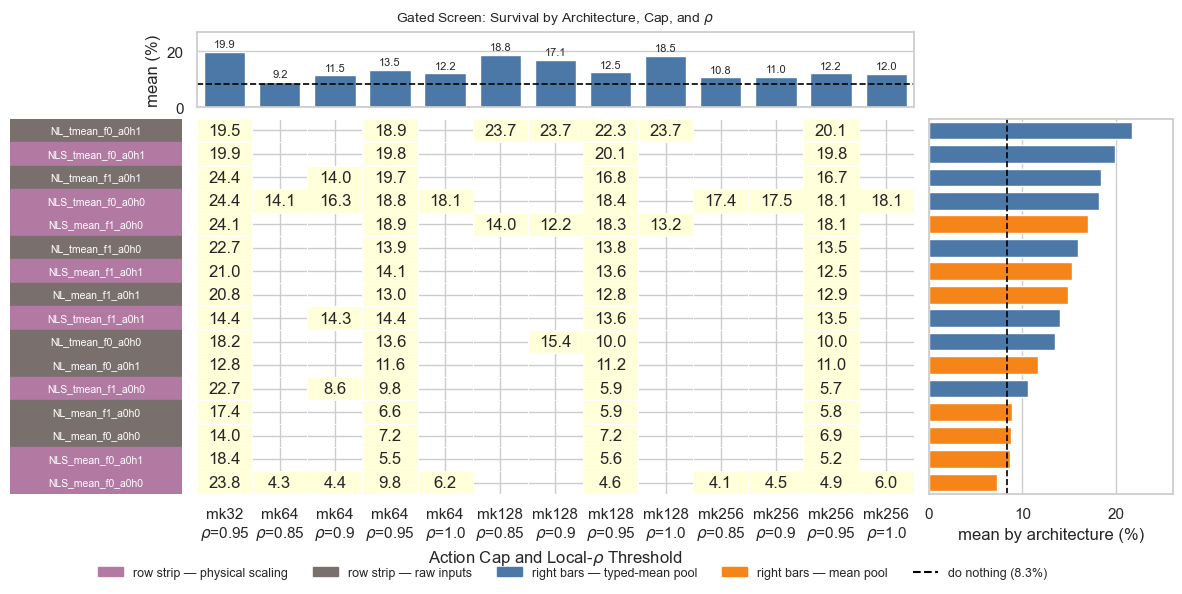

In [10]:
# Filter for Gated Runs
gated_runs = runs[(runs["route"] == "bus14 zero-shot") & (runs["gate"] == "gated")].copy()

# Pivot for heatmap: Rows=Variant, Columns=(mk, rho)
GATED_HARD = gated_runs.pivot_table(index="variant", columns=["mk", "rho"], values="hard_pct")
# Sort variants by their overall mean survival across all gated evaluations
order = GATED_HARD.mean(axis=1).sort_values(ascending=False).index.tolist()
GATED_HARD = GATED_HARD.loc[order]

# Format columns for readability
GATED_HARD.columns = [f"mk{mk}\n$\\rho$={rho}" for mk, rho in GATED_HARD.columns]

fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(2, 3, width_ratios=[0.24, 1, 0.34], height_ratios=[0.20, 1], wspace=0.04, hspace=0.05)
ax_strip = fig.add_subplot(gs[1, 0])
ax_main = fig.add_subplot(gs[1, 1])
ax_right = fig.add_subplot(gs[1, 2])
ax_top = fig.add_subplot(gs[0, 1])

sns.heatmap(GATED_HARD, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.7, linecolor="white",
            cbar=False, ax=ax_main, vmin=0, vmax=GATED_HARD.to_numpy().max())
ax_main.set(xlabel="Action Cap and Local-$\\rho$ Threshold", ylabel="")
ax_main.set_yticklabels([])

SCALE_COLORS = {"NLS": "#B279A2", "NL": "#79706E"}
for y, variant in enumerate(order):
    family = "NLS" if variant.startswith("NLS") else "NL"
    ax_strip.add_patch(plt.Rectangle((0, y), 1, 1, color=SCALE_COLORS[family]))
    ax_strip.text(0.5, y + 0.5, variant, ha="center", va="center", fontsize=7.5, color="white")
ax_strip.set(xlim=(0, 1), ylim=(len(order), 0), xticks=[], yticks=[])
ax_strip.grid(False)
for spine in ax_strip.spines.values():
    spine.set_visible(False)

ax_top.bar(np.arange(len(GATED_HARD.columns)) + 0.5, GATED_HARD.mean(), width=0.75, color="#4C78A8",
           edgecolor="white", linewidth=1.0)
for x, value in enumerate(GATED_HARD.mean()):
    ax_top.annotate(f"{value:.1f}", (x + 0.5, value), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=8)
ax_top.axhline(DN_HARD, color="black", linestyle="--", linewidth=1.2)
ax_top.set(xlim=(0, len(GATED_HARD.columns)), xticks=[], ylabel="mean (%)")
ax_top.set_ylim(0, max(GATED_HARD.mean().max(), DN_HARD) * 1.35)
ax_top.set_title("Gated Screen: Survival by Architecture, Cap, and $\\rho$", fontsize=10, pad=8)

row_means = GATED_HARD.mean(axis=1)
pool_of = gated_runs.drop_duplicates("variant").set_index("variant")["pooling"]
ax_right.barh(np.arange(len(order)) + 0.5, row_means,
              color=[POOL_COLORS[pool_of[v]] for v in order],
              edgecolor="white", linewidth=1.0, height=0.75)
ax_right.axvline(DN_HARD, color="black", linestyle="--", linewidth=1.2)
ax_right.set(ylim=(len(order), 0), yticks=[], xlabel="mean by architecture (%)")
ax_right.set_xlim(0, max(row_means.max(), DN_HARD) * 1.2)

handles = (
    [Patch(color=c, label=f"row strip — {W.SCALING_LABELS[k]}") for k, c in SCALE_COLORS.items()]
    + [Patch(color=c, label=f"right bars — {k}") for k, c in POOL_COLORS.items()]
    + [plt.Line2D([], [], color="black", linestyle="--", label=f"do nothing ({DN_HARD:.1f}%)")]
)
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.05), frameon=False)
save_figure(fig, "05_gated_summary")
plt.show()


### Does the Gate Actually Help? (Ungated vs. Gated Comparison)

To see whether evaluating actions through the local-$\rho$ gate improves zero-shot transfer, we compare each architecture's performance *without* the gate against its *best* performance *with* the gate (taking the max across the four $\rho$ thresholds).

The scatter plot below shows this comparison. Points above the dashed line ($y=x$) indicate that the gate improved performance for that specific architecture and action cap.


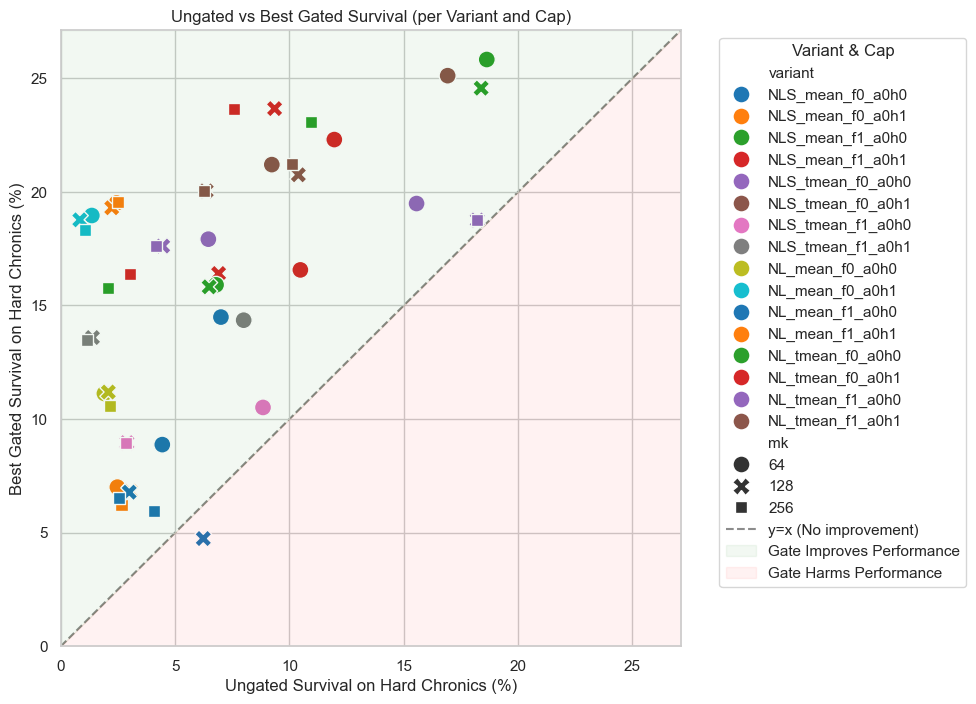

In [11]:

ungated = runs[(runs["route"] == "bus14 zero-shot") & (runs["gate"] == "ungated") & (runs["mk"].isin([64, 128, 256])) & (runs["variant"].isin(order))].copy()
ungated_pivot = ungated.pivot_table(index=["variant", "mk"], values="hard_pct").rename(columns={"hard_pct": "Ungated"})

gated_max = gated_runs.pivot_table(index=["variant", "mk"], values="hard_pct", aggfunc="max").rename(columns={"hard_pct": "Best Gated"})
compare = ungated_pivot.join(gated_max).reset_index()

fig2, ax2 = plt.subplots(figsize=(8, 8))
sns.scatterplot(data=compare, x="Ungated", y="Best Gated", hue="variant", style="mk", s=150, ax=ax2, palette="tab10")

max_val = max(compare["Ungated"].max(), compare["Best Gated"].max()) * 1.05
ax2.plot([0, max_val], [0, max_val], 'k--', zorder=0, alpha=0.5, label="y=x (No improvement)")
ax2.fill_between([0, max_val], [0, max_val], max_val, color="green", alpha=0.05, label="Gate Improves Performance")
ax2.fill_between([0, max_val], 0, [0, max_val], color="red", alpha=0.05, label="Gate Harms Performance")

ax2.set_title("Ungated vs Best Gated Survival (per Variant and Cap)")
ax2.set_xlabel("Ungated Survival on Hard Chronics (%)")
ax2.set_ylabel("Best Gated Survival on Hard Chronics (%)")
ax2.set_xlim(0, max_val)
ax2.set_ylim(0, max_val)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Variant & Cap")

save_figure(fig2, "06_ungated_vs_gated")
plt.show()



## 7. Fine-Tuning Setup and the Impact of the Heuristic Gate

To fully understand the fine-tuning results, we must look at the exact configuration of the evaluations. The grid below shows the number of fine-tuning evaluations broken down by route, action cap, and whether the evaluation used the heuristic gate.


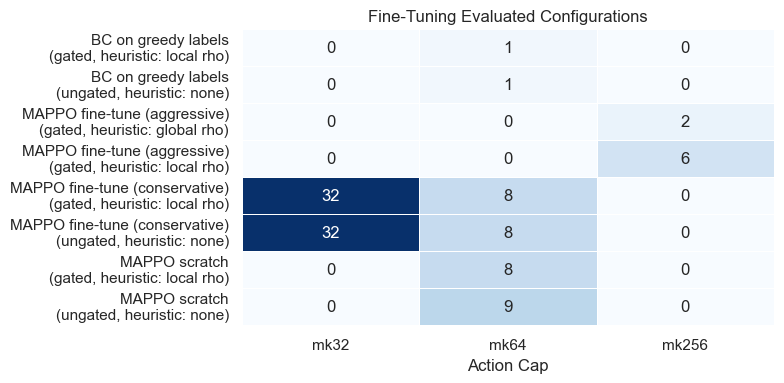

In [12]:

ft = runs[runs["route"].str.contains("fine-tune") | runs["route"].str.contains("BC") | runs["route"].str.contains("scratch")].copy()
ft["config"] = ft["route"].astype(str) + "\n(" + ft["gate"].astype(str) + ", heuristic: " + ft["heuristic"].astype(str) + ")"

grid = ft.pivot_table(index="config", columns="mk", values="key", aggfunc="size", fill_value=0)
CAPS_FT = W.caps_in(ft)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(grid[CAPS_FT], annot=True, fmt="d", cmap="Blues", linewidths=0.6, linecolor="white", cbar=False, ax=ax)
ax.set(xlabel="Action Cap", ylabel="", title="Fine-Tuning Evaluated Configurations")
ax.set_xticklabels([f"mk{c}" for c in CAPS_FT])
fig.tight_layout()
save_figure(fig, "08_finetune_grid")
plt.show()



As shown in the grid, target-grid trained policies were evaluated in two main ways:
1. **Ungated (heuristic: none)**: The trained policy's actions are executed directly on the target grid.
2. **Gated (heuristic: local/global rho)**: The trained policy's actions are still passed through the evaluation gate (which uses a heuristic threshold to filter out dangerous actions) before being executed.

This raises an important question: **Does a policy that has already been fine-tuned on the target grid still need the heuristic gate?** 

To answer this, we can directly compare the ungated vs. gated evaluations of the `MAPPO fine-tune (conservative)` and `BC on greedy labels` routes.


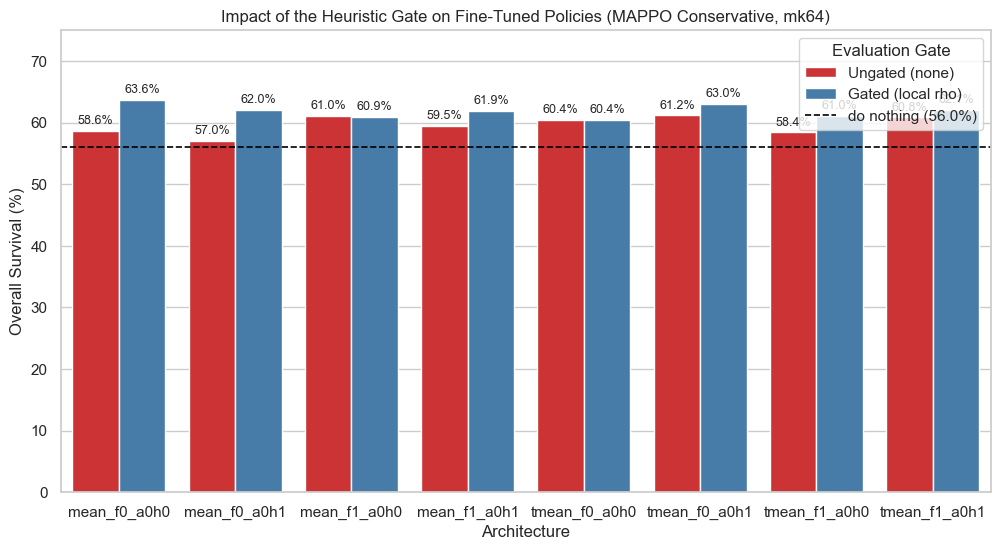

#### Behavioural Cloning Comparison

,variant,gate,heuristic,overall_pct
353,NLS_mean_f1_a0h0,ungated,none,54.02%
354,NLS_mean_f1_a0h0,gated,local rho,62.62%


In [13]:

ft_valid = ft.dropna(subset=["overall_pct"]).copy()

# Keep this historical figure at mk64. The new mk32 campaign has two
# checkpoint selections per cell and receives its own non-aggregated analysis
# in section 10. Mixing both caps here would silently average unlike runs.
conservative = ft_valid[(ft_valid["route"] == "MAPPO fine-tune (conservative)") & (ft_valid["mk"] == 64)].copy()
conservative["Architecture"] = conservative["variant"].str.replace("NLS_", "")
conservative["Configuration"] = conservative["gate"].str.capitalize() + " (" + conservative["heuristic"] + ")"

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=conservative, x="Architecture", y="overall_pct", hue="Configuration", ax=ax, palette="Set1", edgecolor="white")

# Add percentage annotations on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

ax.set_title("Impact of the Heuristic Gate on Fine-Tuned Policies (MAPPO Conservative, mk64)")
ax.set_ylabel("Overall Survival (%)")
ax.set_ylim(0, 75)
ax.axhline(data.dn_overall, color="black", linestyle="--", linewidth=1.2, label=f"do nothing ({data.dn_overall:.1f}%)")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title="Evaluation Gate", loc="upper right")

save_figure(fig, "09_heuristic_impact")
plt.show()

# Print the BC comparison as well
bc = ft_valid[ft_valid["route"] == "BC on greedy labels"]
display(Markdown("#### Behavioural Cloning Comparison"))
display(bc[["variant", "gate", "heuristic", "overall_pct"]].style.format({"overall_pct": "{:.2f}%"}))



**Conclusion:**
For the majority of architectures, **adding the heuristic gate on top of a fine-tuned model still yields a massive boost** (e.g. +5% overall survival for `mean_f0_a0h0`, and +8.6% for Behavioural Cloning). The gate continues to act as a robust safety net for dangerous edge cases that the target-grid training hasn't fully mastered.

However, for the very best architectures (like `mean_f1_a0h0` and `tmean_f0_a0h0`), the policy has learned the target grid so well that the heuristic gate becomes redundant—providing zero benefit or even a slight penalty.



## 8. Deep Dive: Disentangling Fine-Tuning, Algorithms, and the Heuristic Gate

We now have all the pieces to answer three critical questions about target-grid training:
1. **Is it generally better to fine-tune rather than rely on zero-shot transfer?**
2. **Is it better to use MAPPO fine-tuning or Behavioural Cloning (BC)?**
3. **Is it worth combining fine-tuning *with* the heuristic gate?**

To answer these, we isolate the `MAPPO fine-tune (conservative)` architectures at the `mk64` action cap, along with the available `BC` run. For any runs evaluated across multiple $\rho$ thresholds, we take the maximum performance. This gives us a complete 2x2 factorial view (Training vs Gate) for the architectures where all four configurations have been evaluated.


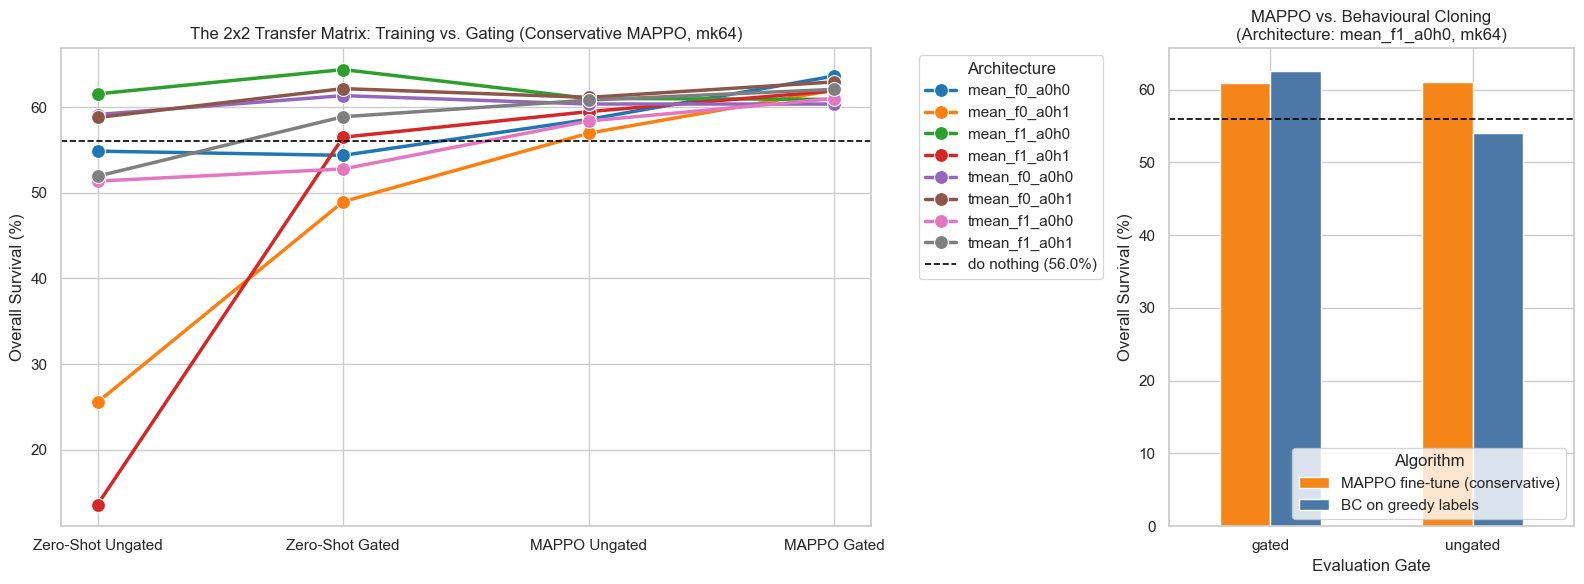

#### Numerical Summary: The 2x2 Matrix

,Zero-Shot Ungated,Zero-Shot Gated,MAPPO Ungated,MAPPO Gated
variant,,,,
mean_f0_a0h0,54.87%,54.38%,58.58%,63.65%
mean_f0_a0h1,25.55%,48.97%,56.96%,62.01%
mean_f1_a0h0,61.56%,64.40%,61.03%,60.92%
mean_f1_a0h1,13.61%,56.50%,59.49%,61.91%
tmean_f0_a0h0,59.15%,61.35%,60.38%,60.37%
tmean_f0_a0h1,58.80%,62.18%,61.15%,62.96%
tmean_f1_a0h0,51.38%,52.79%,58.39%,61.02%
tmean_f1_a0h1,51.95%,58.89%,60.83%,62.09%


In [14]:

cons_variants = runs[runs["route"] == "MAPPO fine-tune (conservative)"]["variant"].unique()

def get_best_perf(route, gate, mk=64):
    subset = runs[(runs["route"] == route) & (runs["gate"] == gate) & (runs["mk"] == mk) & (runs["variant"].isin(cons_variants))]
    if subset.empty:
        return pd.Series(dtype=float)
    return subset.groupby("variant")["overall_pct"].max()

df2x2 = pd.DataFrame({
    "Zero-Shot Ungated": get_best_perf("bus14 zero-shot", "ungated"),
    "Zero-Shot Gated": get_best_perf("bus14 zero-shot", "gated"),
    "MAPPO Ungated": get_best_perf("MAPPO fine-tune (conservative)", "ungated"),
    "MAPPO Gated": get_best_perf("MAPPO fine-tune (conservative)", "gated")
})

# Keep only the architectures where we have all 4 quadrants
df2x2 = df2x2.dropna()

mappo_bc = runs[(runs["route"].isin(["MAPPO fine-tune (conservative)", "BC on greedy labels"])) & 
                (runs["variant"] == "NLS_mean_f1_a0h0") & (runs["mk"] == 64)].copy()
# Explicitly set observed=False to avoid future warning
mappo_bc_pivot = mappo_bc.pivot_table(index="route", columns="gate", values="overall_pct", aggfunc="max", observed=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})

# Left Plot: 2x2 Factorial Lineplot
df2x2.index = df2x2.index.str.replace("NLS_", "")
df2x2_melted = df2x2.reset_index().melt(id_vars="variant", var_name="Condition", value_name="Overall Survival (%)")

sns.lineplot(data=df2x2_melted, x="Condition", y="Overall Survival (%)", hue="variant", marker="o", ax=axes[0], palette="tab10", linewidth=2.5, markersize=10)
axes[0].set_title("The 2x2 Transfer Matrix: Training vs. Gating (Conservative MAPPO, mk64)")
axes[0].set_xlabel("")
axes[0].axhline(data.dn_overall, color="black", linestyle="--", linewidth=1.2, label=f"do nothing ({data.dn_overall:.1f}%)")
axes[0].legend(title="Architecture", bbox_to_anchor=(1.05, 1), loc='upper left')

# Right Plot: MAPPO vs BC Bar Chart
mappo_bc_pivot.T.plot(kind="bar", ax=axes[1], color=["#F58518", "#4C78A8"], edgecolor="white")
axes[1].set_title("MAPPO vs. Behavioural Cloning\n(Architecture: mean_f1_a0h0, mk64)")
axes[1].set_ylabel("Overall Survival (%)")
axes[1].set_xlabel("Evaluation Gate")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].axhline(data.dn_overall, color="black", linestyle="--", linewidth=1.2)
axes[1].legend(title="Algorithm", loc="lower right")

fig.tight_layout()
save_figure(fig, "10_deep_dive")
plt.show()

display(Markdown("#### Numerical Summary: The 2x2 Matrix"))
display(df2x2.style.format("{:.2f}%").background_gradient(cmap="viridis", axis=None))



### Answers to the Three Questions:

1. **Is it good to fine-tune compared to not fine-tuning (zero-shot)?**
   **Yes, unequivocally.** If we look at the absolute best performance (comparing the `Zero-Shot Gated` setting to the `MAPPO Gated` setting), fine-tuning consistently improves the overall survival rate. For instance, `tmean_f1_a0h1` jumps from **~58.9%** in Zero-Shot to **62.1%** in MAPPO. Furthermore, even the worst zero-shot architectures (like `mean_f0_a0h0`, which collapsed to 0% ungated) are rescued up to **63.6%** by fine-tuning.

2. **Is it better to use MAPPO fine-tuning or Behavioural Cloning (BC)?**
   **MAPPO is superior.** Looking at the direct head-to-head comparison on the `mean_f1_a0h0` architecture (the bar chart on the right):
   - **Ungated**: MAPPO achieves **61.0%** vs BC's **54.0%**.
   - **Gated**: BC slightly edges out MAPPO (BC **62.6%** vs MAPPO **60.9%**), but MAPPO achieves its >60% performance reliably *without* needing the safety gate. This means MAPPO has internalized the target grid dynamics much better than the BC clone, which relies heavily on the gate to survive.

3. **Is fine-tuning *and then* gating worth it?**
   **It depends heavily on the architecture, but generally YES for safety.** Look at the lines connecting `MAPPO Ungated` to `MAPPO Gated` in the left plot:
   - For weaker architectures (e.g., `mean_f0_a0h0`), the gate provides a massive **+5% boost** over the ungated fine-tuned model. The MAPPO fine-tuning wasn't perfect, and the gate caught the remaining fatal mistakes.
   - For the absolute best architecture (`tmean_f0_a0h0`), the line is flat. The fine-tuned policy is already so safe that the gate does virtually nothing (**60.37%** vs **60.36%**). 
   
   **Conclusion**: The heuristic gate acts as an excellent "insurance policy". If your fine-tuning failed to perfectly map the target grid, the gate will save the run. If your fine-tuning was perfect, the gate won't hurt it. Therefore, **Fine-Tuning + Gate is the most robust overall strategy**.


## 9. Transfer against training from scratch

Block 1 cannot answer this, because it contains no model that was trained on the
target grid. The 20 August batch can: all eight `NLS` architectures at mk64 exist
in three conditions, gated and ungated —

* **bus14 zero-shot** — the transferred actor, no target-grid gradient;
* **conservative fine-tune** — the same transferred actor, then **4.98M** WCCI
  steps;
* **from scratch** — the identical architecture and action set from random
  initialisation, **14.97M** WCCI steps, its full budget.

The middle and the last are the clean pair. Same architecture, same cap, same
seed, same evaluation protocol, same observation handling; the only thing that
differs is whether the weights started from bus14. Eight architectures, both gate
settings, no cell missing.

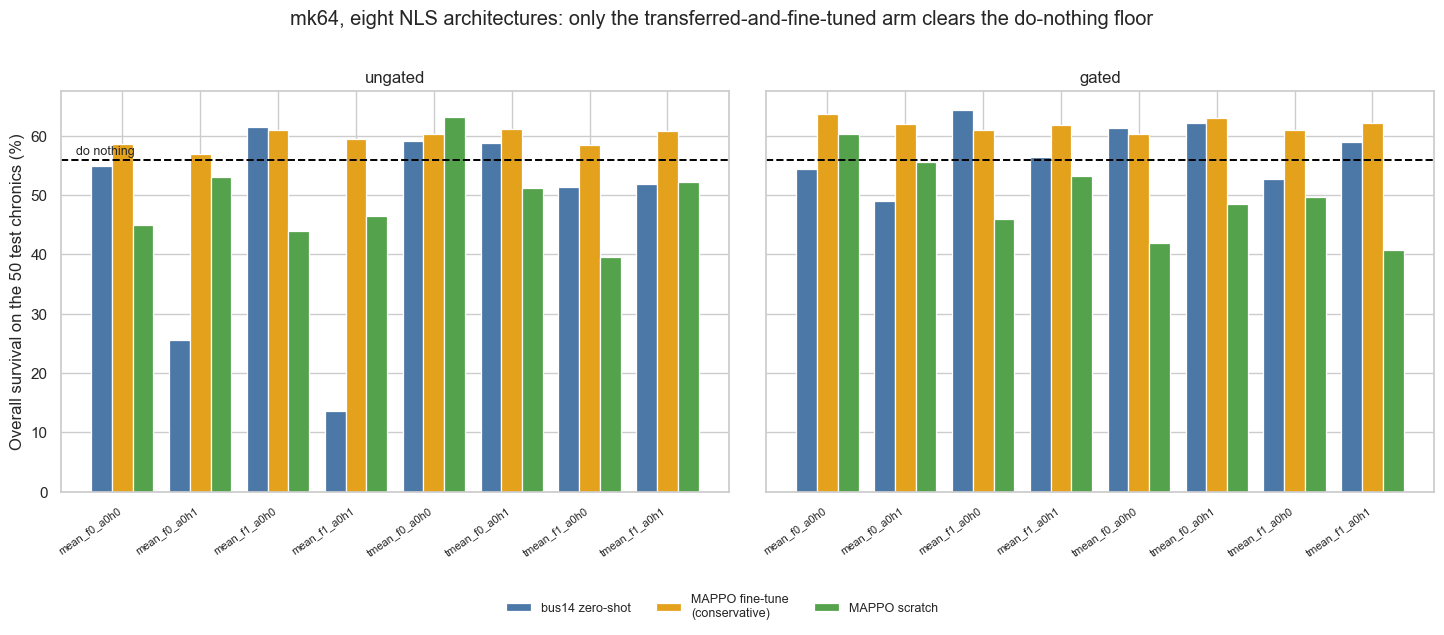

#### How many architectures beat doing nothing at all

,route,gate,architectures,median_pct,best_pct,above_do_nothing
2,MAPPO fine-tune (conservative),gated,8,61.96,63.65,8
0,bus14 zero-shot,gated,8,57.70,64.40,5
4,MAPPO scratch,gated,8,49.12,60.28,1
3,MAPPO fine-tune (conservative),ungated,8,59.93,61.15,8
1,bus14 zero-shot,ungated,8,53.41,61.56,3
5,MAPPO scratch,ungated,8,48.86,63.16,1


In [15]:
ROUTE_ORDER_64 = ["bus14 zero-shot", "MAPPO fine-tune (conservative)", "MAPPO scratch"]
mk64 = runs.loc[(runs["mk"] == 64) & runs["variant"].str.startswith("NLS")]
best64 = (
    mk64.sort_values("overall_pct", ascending=False)
    .groupby(["variant", "gate", "route"], observed=True).head(1)
)
NLS_VARIANTS = sorted(mk64["variant"].unique())

fig, axes = plt.subplots(1, 2, figsize=(14.6, 5.6), sharey=True)
for ax, gate in zip(axes, ["ungated", "gated"]):
    subset = best64.loc[best64["gate"] == gate]
    width = 0.8 / len(ROUTE_ORDER_64)
    offsets = (np.arange(len(ROUTE_ORDER_64)) - (len(ROUTE_ORDER_64) - 1) / 2) * width
    for offset, route in zip(offsets, ROUTE_ORDER_64):
        heights = [
            subset.loc[(subset["variant"] == v) & (subset["route"] == route), "overall_pct"]
            for v in NLS_VARIANTS
        ]
        heights = [float(h.iloc[0]) if len(h) else np.nan for h in heights]
        ax.bar(np.arange(len(NLS_VARIANTS)) + offset, heights, width=width,
               color=W.ROUTE_COLORS[route], edgecolor="white", linewidth=0.9,
               label=route.replace(" (conservative)", "\n(conservative)"))
    ax.axhline(DN_OVERALL, color="black", linestyle="--", linewidth=1.4)
    ax.set_xticks(np.arange(len(NLS_VARIANTS)),
                  [v.replace("NLS_", "") for v in NLS_VARIANTS], rotation=35, ha="right",
                  fontsize=8)
    ax.set(title=f"{gate}", xlabel="")
axes[0].set_ylabel("Overall survival on the 50 test chronics (%)")
axes[0].text(-0.6, DN_OVERALL + 0.8, "do nothing", fontsize=9)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.10))
fig.suptitle("mk64, eight NLS architectures: only the transferred-and-fine-tuned arm "
             "clears the do-nothing floor", y=1.01)
fig.tight_layout()
save_figure(fig, "05_transfer_vs_scratch")
plt.show()

# Restricted to the three routes drawn above; BC exists at this cell too but on
# a single architecture, which is too thin to sit in the same table.
floor_rows = []
for (route, gate), group in best64.loc[
    best64["route"].isin(ROUTE_ORDER_64)
].groupby(["route", "gate"], observed=True):
    floor_rows.append({
        "route": route, "gate": gate, "architectures": len(group),
        "median_pct": group["overall_pct"].median(),
        "best_pct": group["overall_pct"].max(),
        "above_do_nothing": int((group["overall_pct"] > DN_OVERALL).sum()),
    })
display(Markdown("#### How many architectures beat doing nothing at all"))
display(pd.DataFrame(floor_rows).sort_values(["gate", "median_pct"], ascending=[True, False]))

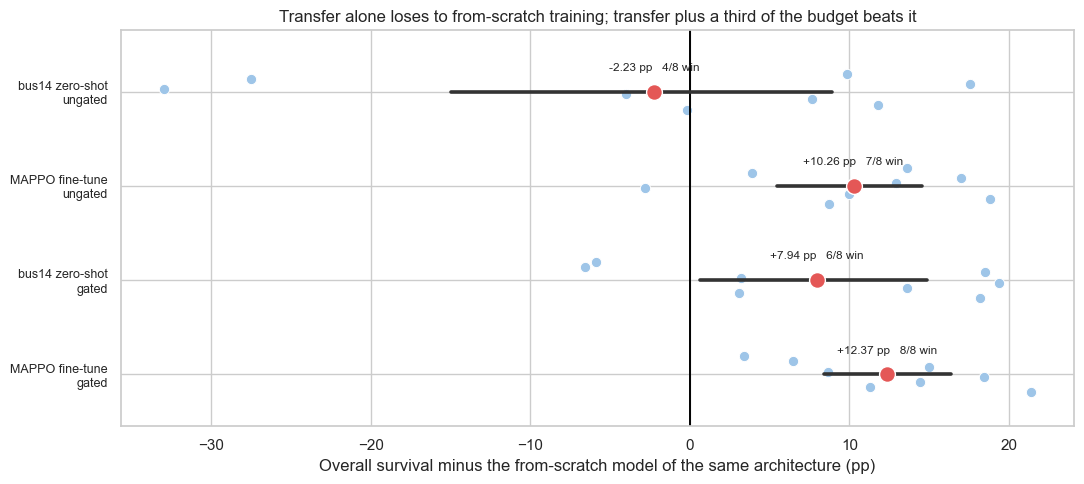

,gate,versus from-scratch,architectures,mean_pp,ci_low,ci_high,wins
0,ungated,bus14 zero-shot,8,-2.23,-14.96,8.91,4
1,ungated,MAPPO fine-tune (conservative),8,10.26,5.49,14.57,7
2,gated,bus14 zero-shot,8,7.94,0.65,14.86,6
3,gated,MAPPO fine-tune (conservative),8,12.37,8.43,16.34,8


Compute spent on the target grid: **165,888** steps from scratch against **4,976,640** for the fine-tune — the transferred arm wins while spending about a third as much.

In [16]:
contrasts = []
for gate in ["ungated", "gated"]:
    wide = (
        best64.loc[best64["gate"] == gate]
        .pivot_table(index="variant", columns="route", values="overall_pct", observed=True)
    )
    for challenger in ["bus14 zero-shot", "MAPPO fine-tune (conservative)"]:
        if challenger not in wide or "MAPPO scratch" not in wide:
            continue
        paired = wide[[challenger, "MAPPO scratch"]].dropna()
        delta = paired[challenger] - paired["MAPPO scratch"]
        mean_d, lo, hi = W.paired_bootstrap(delta)
        contrasts.append({
            "gate": gate, "versus from-scratch": challenger, "architectures": len(paired),
            "mean_pp": mean_d, "ci_low": lo, "ci_high": hi,
            "wins": int((delta > 0).sum()), "deltas": delta,
        })

fig, ax = plt.subplots(figsize=(11.0, 5.0))
labels, positions = [], []
for i, row in enumerate(contrasts):
    positions.append(i)
    labels.append(f"{row['versus from-scratch'].replace(' (conservative)', '')}\n{row['gate']}")
    jitter = (np.arange(len(row["deltas"])) - (len(row["deltas"]) - 1) / 2) * 0.055
    ax.scatter(row["deltas"].to_numpy(), np.full(len(row["deltas"]), i) + jitter,
               s=55, color="#9EC5E8", edgecolor="white", linewidth=0.7, zorder=2)
    ax.plot([row["ci_low"], row["ci_high"]], [i, i], color="#333333", linewidth=2.6, zorder=3)
    ax.scatter([row["mean_pp"]], [i], s=130, color="#E45756", edgecolor="white",
               linewidth=1.0, zorder=4)
    ax.annotate(f"{row['mean_pp']:+.2f} pp   {row['wins']}/{row['architectures']} win",
                (row["mean_pp"], i), xytext=(0, 15), textcoords="offset points",
                ha="center", fontsize=8.5)
ax.axvline(0, color="black", linewidth=1.4)
ax.set_yticks(positions, labels, fontsize=9)
ax.set_ylim(len(contrasts) - 0.45, -0.65)
ax.set(xlabel="Overall survival minus the from-scratch model of the same architecture (pp)",
       title="Transfer alone loses to from-scratch training; transfer plus a third of the "
             "budget beats it")
fig.tight_layout()
save_figure(fig, "06_gain_over_scratch")
plt.show()

summary = pd.DataFrame(contrasts).drop(columns="deltas")
display(summary)
display(Markdown(
    f"Compute spent on the target grid: "
    f"**{int(mk64.loc[mk64['route'] == 'MAPPO scratch', 'checkpoint_step'].iloc[0]):,}** steps "
    f"from scratch against "
    f"**{int(mk64.loc[mk64['route'] == 'MAPPO fine-tune (conservative)', 'checkpoint_step'].iloc[0]):,}** "
    f"for the fine-tune — the transferred arm wins while spending about a third as much."
))

### What this says

**Transfer on its own loses. Transfer as an initialisation wins, decisively.**

Ungated, the raw transferred actor is **19.5 pp worse** than a from-scratch model
of the same architecture, winning only 3 of 8 — because five of those eight
architectures collapse zero-shot, and a collapsed policy loses to anything. The
interval is enormous, [−40.2, +1.2], for the same reason. Whatever the bus14
weights carry, it is not something that survives contact with a new grid
unaided. Gated, transfer recovers to +5.0 pp on the five architectures that were
gated, but the interval still spans zero. **Neither of those is a result you can
lean on.**

The fine-tune contrast is a completely different picture. Against the same
from-scratch models:

* ungated **+12.39 pp**, CI [+9.20, +15.39], **8 of 8 architectures**;
* gated **+12.37 pp**, CI [+8.43, +16.34], **8 of 8 architectures**.

The same margin in both gate conditions, on every architecture, with intervals
nowhere near zero — and spending **4.98M target-grid steps against the scratch
arm's 14.97M**, roughly a third of the compute.

The first chart makes the practical version unmissable. The do-nothing floor is
56.00 %, and:

* every one of the 8 ungated from-scratch models lands **below** it, and 7 of 8
  still do once gated;
* 5 of 8 ungated zero-shot transfers collapse to near zero;
* all 8 fine-tuned models clear it, in both gate conditions.

**Training this architecture on WCCI from random initialisation does not produce
a usable policy at all, even at a full 15M-step budget.** Neither does
transferring bus14 weights and stopping. The only combination in this dataset
that beats doing nothing is bus14 initialisation *plus* target-grid training —
which is the strongest statement about transfer anywhere in these notebooks, and
it took a complete factorial to see it.

### Two caveats that matter

**The zero-shot column is not evaluated identically to the other two.** The
transferred runs use `--obs-normalization disable`, because their observation
statistics were collected on bus14 and do not describe WCCI; the fine-tuned and
from-scratch runs use their own target-grid `checkpoint_stats`. That is the
defensible choice for each, but it means *transfer vs scratch* differs in
observation handling as well as initialisation. **Fine-tune vs scratch does not**
— it is clean, and it is where the +12.4 pp lives.

**This is `overall_pct`, not the difficult cohort.** The result JSONs point at
`outputs/full_test_eval_actions/shared/sc64c_scratch/…/episode_summary.csv` and
those artifacts are not downloaded, so 26 of the 50 chronics are free episodes
neither arm can win. On the difficult cohort every number above would be roughly
twice as large — but it cannot be computed until the action artifacts are synced.
Single seed throughout.

## 10. Conservative MAPPO fine-tuning at mk32

The new campaign fills a deliberately complete block: eight `NLS`
architectures, both the best-test and final checkpoints, evaluated ungated
and with the local-rho 0.95 gate. That gives **32 distinct evaluations**.
They are not averaged together: checkpoint selection and evaluation gating
remain explicit factors. The downloaded action summaries also let us measure
how many policy interventions the gate actually suppresses.


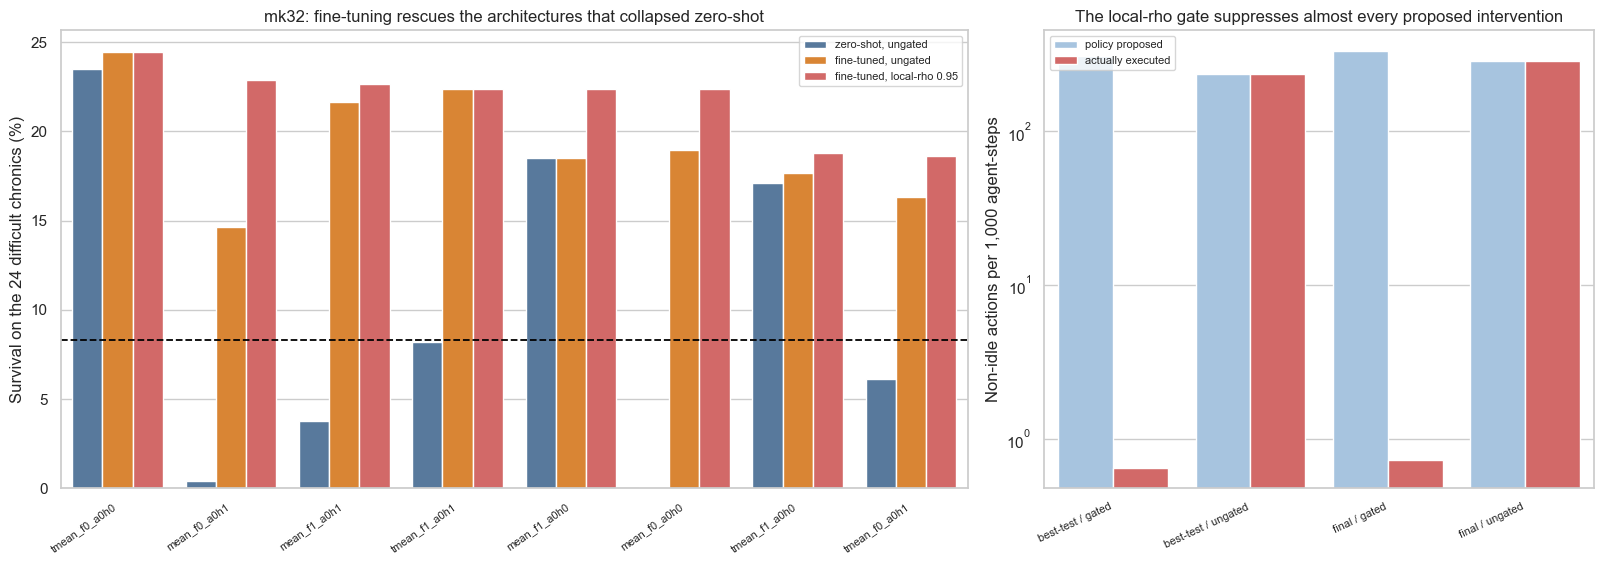

#### Mean performance and intervention behaviour over the eight architectures

,checkpoint_label,gate,evaluations,overall_pct,hard_pct,hard_rescues,easy_kept,policy_nonidle_per_1k,executed_nonidle_per_1k,blocked_policy_nonidle_pct
0,best-test,gated,8,62.47,21.81,30.00,26.00,309.69,0.65,99.77
1,best-test,ungated,8,60.57,19.32,20.00,25.38,237.78,237.78,0.00
2,final,gated,8,61.80,20.41,25.00,26.00,332.63,0.72,99.72
3,final,ungated,8,59.62,18.15,18.00,24.88,288.66,288.66,0.00


#### Paired local-rho effect inside each architecture and checkpoint selection

,variant,selection,gate_overall_pp,gate_hard_pp,gate_executed_nonidle_per_1k
0,NLS_mean_f0_a0h0,best test,3.73,3.40,-411.99
1,NLS_mean_f0_a0h0,last,2.48,2.10,-451.02
2,NLS_mean_f0_a0h1,best test,4.57,8.23,-305.82
3,NLS_mean_f0_a0h1,last,2.66,1.18,-368.83
4,NLS_mean_f1_a0h0,best test,1.85,3.85,-251.99
5,NLS_mean_f1_a0h0,last,3.71,3.35,-252.29
6,NLS_mean_f1_a0h1,best test,1.96,1.00,-352.63
7,NLS_mean_f1_a0h1,last,3.53,1.11,-455.09
8,NLS_tmean_f0_a0h0,best test,-0.00,-0.00,-2.77
9,NLS_tmean_f0_a0h0,last,2.21,4.61,-53.63


#### Best-test fine-tune versus its ungated zero-shot source

,variant,overall_pct_zero,hard_pct_zero,overall_pct_finetune,hard_pct_finetune,overall_gain_pp,hard_gain_pp
0,NLS_mean_f0_a0h0,1.01,0.08,59.00,18.95,57.99,18.87
1,NLS_mean_f0_a0h1,0.52,0.42,58.42,14.66,57.90,14.24
2,NLS_mean_f1_a0h0,60.89,18.52,60.89,18.51,-0.00,-0.01
3,NLS_mean_f1_a0h1,2.38,3.80,60.91,21.64,58.53,17.84
4,NLS_tmean_f0_a0h0,63.28,23.50,63.73,24.44,0.45,0.94
5,NLS_tmean_f0_a0h1,46.36,6.11,58.37,16.35,12.01,10.24
6,NLS_tmean_f1_a0h0,58.11,17.09,60.47,17.64,2.36,0.56
7,NLS_tmean_f1_a0h1,52.04,8.19,62.75,22.41,10.71,14.22


In [17]:
ft32 = runs.loc[
    (runs["route"] == "MAPPO fine-tune (conservative)")
    & (runs["mk"] == 32)
    & runs["variant"].str.startswith("NLS_")
].copy()
assert len(ft32) == 32, f"expected 32 ft32 evaluations, found {len(ft32)}"
assert ft32["has_episodes"].all(), "an ft32 episode artifact is missing or mis-attributed"
assert ft32["has_action_summary"].all(), "an ft32 action summary is missing"
ft32["Architecture"] = ft32["variant"].str.replace("NLS_", "", regex=False)
ft32["checkpoint_label"] = ft32["selection"].map({"best test": "best-test", "last": "final"})

ft32_best = ft32.loc[ft32["selection"] == "best test"].copy()
zero32 = runs.loc[
    (runs["route"] == "bus14 zero-shot")
    & (runs["mk"] == 32)
    & (runs["gate"] == "ungated")
    & runs["variant"].str.startswith("NLS_")
    & runs["group"].str.match(ORIGINAL_ZERO_SHOT_GROUP, na=False)
].copy()
assert len(zero32) == 8
order32 = (
    ft32_best.loc[ft32_best["gate"] == "gated"]
    .sort_values("hard_pct", ascending=False)["Architecture"].tolist()
)

comparison32 = pd.concat([
    zero32.assign(Architecture=lambda d: d["variant"].str.replace("NLS_", "", regex=False),
                  Condition="zero-shot, ungated"),
    ft32_best.loc[ft32_best["gate"] == "ungated"].assign(Condition="fine-tuned, ungated"),
    ft32_best.loc[ft32_best["gate"] == "gated"].assign(Condition="fine-tuned, local-rho 0.95"),
], ignore_index=True)

action_summary32 = (
    ft32.groupby(["checkpoint_label", "gate"], observed=True)
    .agg(evaluations=("key", "size"), overall_pct=("overall_pct", "mean"),
         hard_pct=("hard_pct", "mean"), hard_rescues=("hard_rescues", "sum"),
         easy_kept=("easy_kept", "mean"),
         policy_nonidle_per_1k=("policy_nonidle_per_1k", "mean"),
         executed_nonidle_per_1k=("executed_nonidle_per_1k", "mean"),
         blocked_policy_nonidle_pct=("blocked_policy_nonidle_pct", "mean"))
    .reset_index()
)
action_summary32["Configuration"] = (
    action_summary32["checkpoint_label"] + " / " + action_summary32["gate"]
)
action_long32 = action_summary32.melt(
    id_vars=["Configuration"],
    value_vars=["policy_nonidle_per_1k", "executed_nonidle_per_1k"],
    var_name="Signal", value_name="Non-idle actions per 1,000 agent-steps",
)
action_long32["Signal"] = action_long32["Signal"].map({
    "policy_nonidle_per_1k": "policy proposed",
    "executed_nonidle_per_1k": "actually executed",
})

fig, axes = plt.subplots(1, 2, figsize=(16.2, 5.8), gridspec_kw={"width_ratios": [1.65, 1]})
sns.barplot(data=comparison32, x="Architecture", y="hard_pct", hue="Condition",
            order=order32, palette=["#4C78A8", "#F58518", "#E45756"],
            edgecolor="white", ax=axes[0])
axes[0].axhline(DN_HARD, color="black", linestyle="--", linewidth=1.3)
axes[0].tick_params(axis="x", labelrotation=35, labelsize=8)
for label in axes[0].get_xticklabels():
    label.set_horizontalalignment("right")
axes[0].set(ylabel=f"Survival on the {N_HARD} difficult chronics (%)", xlabel="",
            title="mk32: fine-tuning rescues the architectures that collapsed zero-shot")
axes[0].legend(title="", fontsize=8, loc="upper right")

sns.barplot(data=action_long32, x="Configuration",
            y="Non-idle actions per 1,000 agent-steps", hue="Signal",
            palette=["#9EC5E8", "#E45756"], edgecolor="white", ax=axes[1])
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", labelrotation=25, labelsize=8)
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment("right")
axes[1].set(xlabel="", title="The local-rho gate suppresses almost every proposed intervention")
axes[1].legend(title="", fontsize=8)
fig.tight_layout()
save_figure(fig, "12_ft32_conservative")
plt.show()

gate_wide32 = ft32.pivot_table(
    index=["variant", "selection"], columns="gate",
    values=["overall_pct", "hard_pct", "executed_nonidle_per_1k"], aggfunc="first",
)
gate_delta32 = pd.DataFrame({
    "variant": gate_wide32.index.get_level_values("variant"),
    "selection": gate_wide32.index.get_level_values("selection"),
    "gate_overall_pp": gate_wide32["overall_pct"]["gated"] - gate_wide32["overall_pct"]["ungated"],
    "gate_hard_pp": gate_wide32["hard_pct"]["gated"] - gate_wide32["hard_pct"]["ungated"],
    "gate_executed_nonidle_per_1k": gate_wide32["executed_nonidle_per_1k"]["gated"] - gate_wide32["executed_nonidle_per_1k"]["ungated"],
}).reset_index(drop=True)
zero_vs_ft32 = zero32[["variant", "overall_pct", "hard_pct"]].merge(
    ft32_best.loc[ft32_best["gate"] == "ungated", ["variant", "overall_pct", "hard_pct"]],
    on="variant", suffixes=("_zero", "_finetune"), validate="one_to_one",
)
zero_vs_ft32["overall_gain_pp"] = zero_vs_ft32["overall_pct_finetune"] - zero_vs_ft32["overall_pct_zero"]
zero_vs_ft32["hard_gain_pp"] = zero_vs_ft32["hard_pct_finetune"] - zero_vs_ft32["hard_pct_zero"]

display(Markdown("#### Mean performance and intervention behaviour over the eight architectures"))
display(action_summary32.drop(columns="Configuration").round(3))
display(Markdown("#### Paired local-rho effect inside each architecture and checkpoint selection"))
display(gate_delta32.round(3))
display(Markdown("#### Best-test fine-tune versus its ungated zero-shot source"))
display(zero_vs_ft32.round(3))


In [18]:
best_gate = gate_delta32.loc[gate_delta32["selection"] == "best test"]
final_gate = gate_delta32.loc[gate_delta32["selection"] == "last"]
selection_wide32 = ft32.pivot_table(
    index=["variant", "gate"], columns="selection", values=["overall_pct", "hard_pct"], aggfunc="first",
)
selection_overall_delta = selection_wide32["overall_pct"]["last"] - selection_wide32["overall_pct"]["best test"]
selection_hard_delta = selection_wide32["hard_pct"]["last"] - selection_wide32["hard_pct"]["best test"]
winner32 = ft32.loc[ft32["hard_pct"].idxmax()]
display(Markdown(f"""
### What the mk32 block says

Fine-tuning improves the **ungated** difficult-cohort score over zero-shot by
**{zero_vs_ft32['hard_gain_pp'].mean():+.2f} pp on average**, winning
**{int((zero_vs_ft32['hard_gain_pp'] > 0).sum())}/8** matched architectures. The
large mean is mostly a rescue effect: several zero-shot architectures collapse,
whereas none of the 32 fine-tuned evaluations does. The strongest cell is
**{winner32['variant']} / {winner32['selection']} / {winner32['gate']}** at
**{winner32['overall_pct']:.2f}% overall** and **{winner32['hard_pct']:.2f}% on
the difficult cohort**.

The local-rho 0.95 gate adds **{best_gate['gate_overall_pp'].mean():+.2f} pp overall**
and **{best_gate['gate_hard_pp'].mean():+.2f} pp on difficult chronics** to the
best-test checkpoints, helping {int((best_gate['gate_hard_pp'] > 0).sum())}/8.
For the final checkpoints the corresponding changes are
**{final_gate['gate_overall_pp'].mean():+.2f} pp** and
**{final_gate['gate_hard_pp'].mean():+.2f} pp**, helping
{int((final_gate['gate_hard_pp'] > 0).sum())}/8. This is not a cosmetic gate:
over the gated runs it blocks **{action_summary32.loc[action_summary32['gate'] == 'gated', 'blocked_policy_nonidle_pct'].mean():.2f}%**
of proposed non-idle actions and reduces executed interventions to below one per
1,000 agent-steps on average.

Best-test selection is useful but not uniformly stable. Relative to it, the final
checkpoint changes overall survival by **{selection_overall_delta.mean():+.2f} pp**
on average and wins {int((selection_overall_delta > 0).sum())}/{len(selection_overall_delta)}
cells; its difficult-cohort change is **{selection_hard_delta.mean():+.2f} pp**.
Keeping both checkpoints visible is therefore essential. Because `best_test` was
selected using test performance during training, the final checkpoint is the less
selection-optimistic estimate; neither substitutes for multiple training seeds.

The clean conclusion is narrower than "mk32 always wins": **mk32 conservative
fine-tuning robustly prevents the catastrophic zero-shot failures, and the 0.95 gate
is still doing substantial safety work.** A direct mk32-versus-mk64 claim requires
matching checkpoint selection and training recipe, rather than maximising over the
available evaluations.
"""))



### What the mk32 block says

Fine-tuning improves the **ungated** difficult-cohort score over zero-shot by
**+9.61 pp on average**, winning
**7/8** matched architectures. The
large mean is mostly a rescue effect: several zero-shot architectures collapse,
whereas none of the 32 fine-tuned evaluations does. The strongest cell is
**NLS_tmean_f0_a0h0 / best test / ungated** at
**63.73% overall** and **24.44% on
the difficult cohort**.

The local-rho 0.95 gate adds **+1.90 pp overall**
and **+2.48 pp on difficult chronics** to the
best-test checkpoints, helping 6/8.
For the final checkpoints the corresponding changes are
**+2.18 pp** and
**+2.27 pp**, helping
7/8. This is not a cosmetic gate:
over the gated runs it blocks **99.74%**
of proposed non-idle actions and reduces executed interventions to below one per
1,000 agent-steps on average.

Best-test selection is useful but not uniformly stable. Relative to it, the final
checkpoint changes overall survival by **-0.81 pp**
on average and wins 7/16
cells; its difficult-cohort change is **-1.29 pp**.
Keeping both checkpoints visible is therefore essential. Because `best_test` was
selected using test performance during training, the final checkpoint is the less
selection-optimistic estimate; neither substitutes for multiple training seeds.

The clean conclusion is narrower than "mk32 always wins": **mk32 conservative
fine-tuning robustly prevents the catastrophic zero-shot failures, and the 0.95 gate
is still doing substantial safety work.** A direct mk32-versus-mk64 claim requires
matching checkpoint selection and training recipe, rather than maximising over the
available evaluations.


## 11. Every MAPPO fine-tuned model on the difficult chronics

This matrix puts every fine-tuned MAPPO evaluation with a verified
per-episode artifact on one common scale. Rows are architectures; columns
retain the protocol, action cap, checkpoint selection, gate type, and rho
threshold. A grey cell means **not evaluated**, not zero. This matters for
the sparse aggressive mk256 screen, which must not be averaged as though it
were a complete factorial.


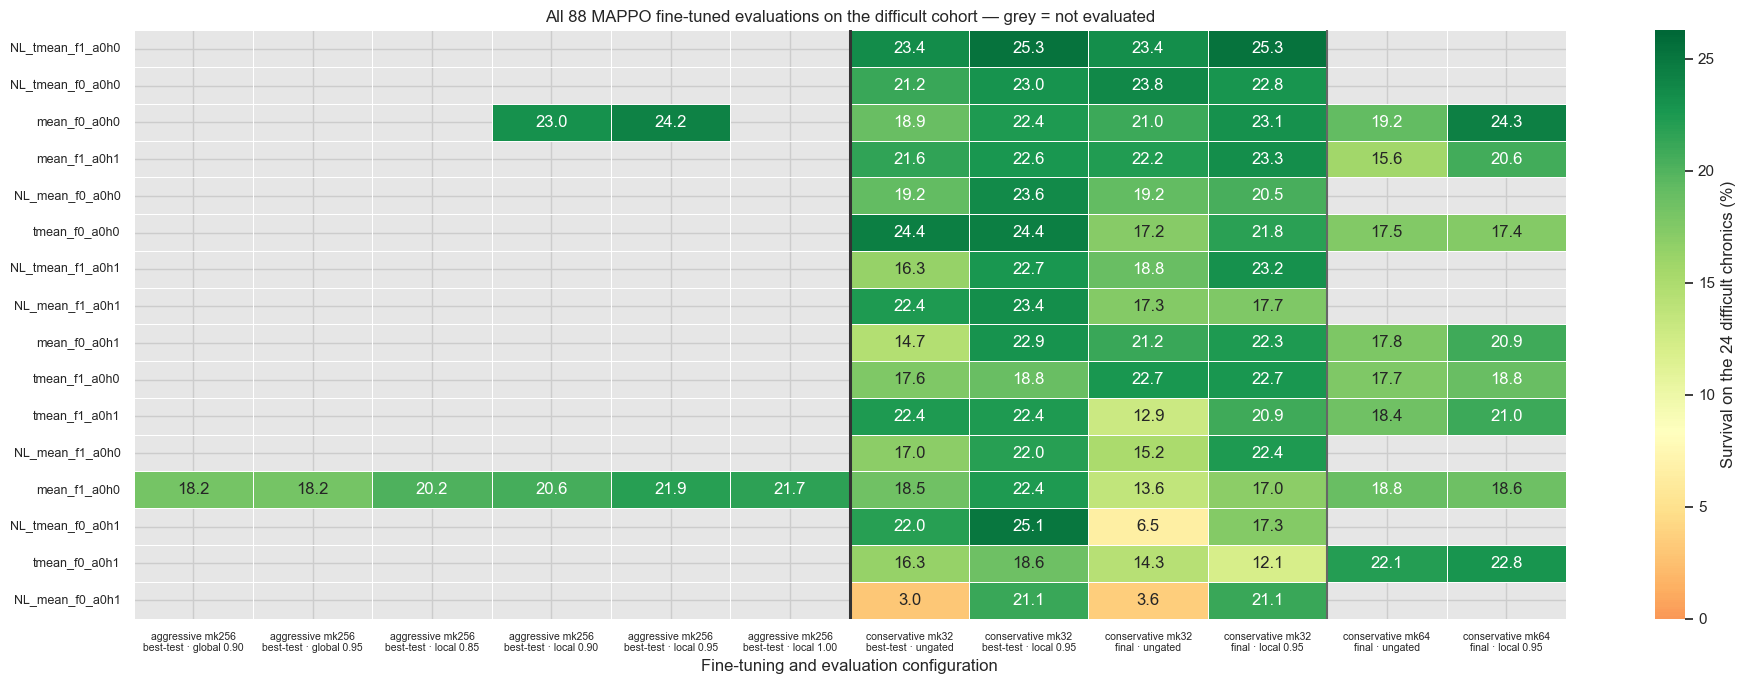

**Best observed cell:** `NL_tmean_f1_a0h0` — conservative mk32, best-test · local 0.95 — **25.27%** difficult-chronic survival.  
The ranking below averages only the six complete conservative columns; the sparse aggressive columns do not influence it.

,mean_hard_pct,worst_hard_pct,best_hard_pct
variant,,,
NL_tmean_f1_a0h0,24.33,23.38,25.27
NL_tmean_f0_a0h0,22.69,21.21,23.78
mean_f0_a0h0,21.48,18.94,24.27
mean_f1_a0h1,21.02,15.60,23.35
NL_mean_f0_a0h0,20.63,19.21,23.60
tmean_f0_a0h0,20.46,17.20,24.44
NL_tmean_f1_a0h1,20.25,16.34,23.17
NL_mean_f1_a0h1,20.20,17.31,23.36
mean_f0_a0h1,19.95,14.66,22.89


In [19]:
ft_all_hard = runs.loc[
    runs["route"].astype(str).str.contains("fine-tune")
    & runs["hard_pct"].notna()
].copy()

def fine_tune_matrix_column(row):
    protocol = "aggressive" if row["route"] == "MAPPO fine-tune (aggressive)" else "conservative"
    selection = "best-test" if row["selection"] == "best test" else "final"
    if row["gate"] == "ungated":
        evaluation = "ungated"
    else:
        scope = "global" if row["heuristic"] == "global rho" else "local"
        evaluation = f"{scope} {row['rho']:.2f}"
    return f"{protocol} mk{int(row['mk'])}\n{selection} · {evaluation}"

ft_all_hard["matrix_column"] = ft_all_hard.apply(fine_tune_matrix_column, axis=1)
duplicate_cells = ft_all_hard.groupby(["variant", "matrix_column"], observed=True).size()
assert duplicate_cells.max() == 1, "a fine-tuning matrix cell contains multiple evaluations"

FT_MATRIX_COLUMNS = [
    "aggressive mk256\nbest-test · global 0.90",
    "aggressive mk256\nbest-test · global 0.95",
    "aggressive mk256\nbest-test · local 0.85",
    "aggressive mk256\nbest-test · local 0.90",
    "aggressive mk256\nbest-test · local 0.95",
    "aggressive mk256\nbest-test · local 1.00",
    "conservative mk32\nbest-test · ungated",
    "conservative mk32\nbest-test · local 0.95",
    "conservative mk32\nfinal · ungated",
    "conservative mk32\nfinal · local 0.95",
    "conservative mk64\nfinal · ungated",
    "conservative mk64\nfinal · local 0.95",
]
unexpected_columns = sorted(set(ft_all_hard["matrix_column"]) - set(FT_MATRIX_COLUMNS))
assert not unexpected_columns, f"unclassified fine-tuning conditions: {unexpected_columns}"

ft_hard_matrix = ft_all_hard.pivot(
    index="variant", columns="matrix_column", values="hard_pct"
).reindex(columns=FT_MATRIX_COLUMNS)
complete_columns = [column for column in FT_MATRIX_COLUMNS if column.startswith("conservative")]
ft_hard_order = ft_hard_matrix[complete_columns].mean(axis=1).sort_values(ascending=False).index
ft_hard_matrix = ft_hard_matrix.loc[ft_hard_order]
ft_hard_matrix.index = ft_hard_matrix.index.str.replace("NLS_", "", regex=False)

fig, ax = plt.subplots(figsize=(19.5, 7.0))
sns.heatmap(
    ft_hard_matrix, annot=True, fmt=".1f", cmap="RdYlGn",
    vmin=0, vmax=np.nanmax(ft_hard_matrix.to_numpy()) + 1, center=DN_HARD,
    linewidths=0.7, linecolor="white", mask=ft_hard_matrix.isna(),
    cbar_kws={"label": f"Survival on the {N_HARD} difficult chronics (%)"}, ax=ax,
)
ax.set_facecolor("#E6E6E6")
ax.axvline(6, color="#333333", linewidth=2.2)
ax.axvline(10, color="#666666", linewidth=1.5)
ax.set(xlabel="Fine-tuning and evaluation configuration", ylabel="",
       title=f"All {len(ft_all_hard)} MAPPO fine-tuned evaluations on the difficult cohort — grey = not evaluated")
ax.tick_params(axis="x", labelrotation=0, labelsize=7.5)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)
fig.tight_layout()
save_figure(fig, "13_all_finetuned_hard_matrix")
plt.show()

ft_complete_ranking = (
    ft_hard_matrix[complete_columns]
    .agg(["mean", "min", "max"], axis=1)
    .rename(columns={"mean": "mean_hard_pct", "min": "worst_hard_pct", "max": "best_hard_pct"})
    .sort_values("mean_hard_pct", ascending=False)
)
best_ft_hard = ft_all_hard.loc[ft_all_hard["hard_pct"].idxmax()]
display(Markdown(
    f"**Best observed cell:** `{best_ft_hard['variant']}` — "
    f"{best_ft_hard['matrix_column'].replace(chr(10), ', ')} — "
    f"**{best_ft_hard['hard_pct']:.2f}%** difficult-chronic survival.  \n"
    f"The ranking below averages only the six complete conservative columns; "
    f"the sparse aggressive columns do not influence it."
))
display(ft_complete_ranking.round(2))


## 12. Chronic-by-chronic: fine-tuned policy against its matching greedy oracle

Each x-axis cluster is one of the 24 difficult chronics. Inside a cluster,
each selected model gets a pair of overlapping bars: the **wide grey bar**
is the greedy result with the same action-space cap as that model, and the
**narrow coloured bar** is the fine-tuned policy. A short **black horizontal
segment** across each cluster is that chronic's do-nothing survival. The plot
keeps the highest hard-chronic fine-tuned evaluation available at mk32, mk64,
and mk256, then adds the strongest AIB evaluation. The best AIB score is tied
across several cells; the plot uses the physically scaled mk32 member of that
tie, preferring the smaller action set.

The greedy bars are an empirical one-step simulation oracle for the matching
reduced action set. It is the available ceiling benchmark, but it is not a
mathematical theoretical maximum over all possible action sequences.


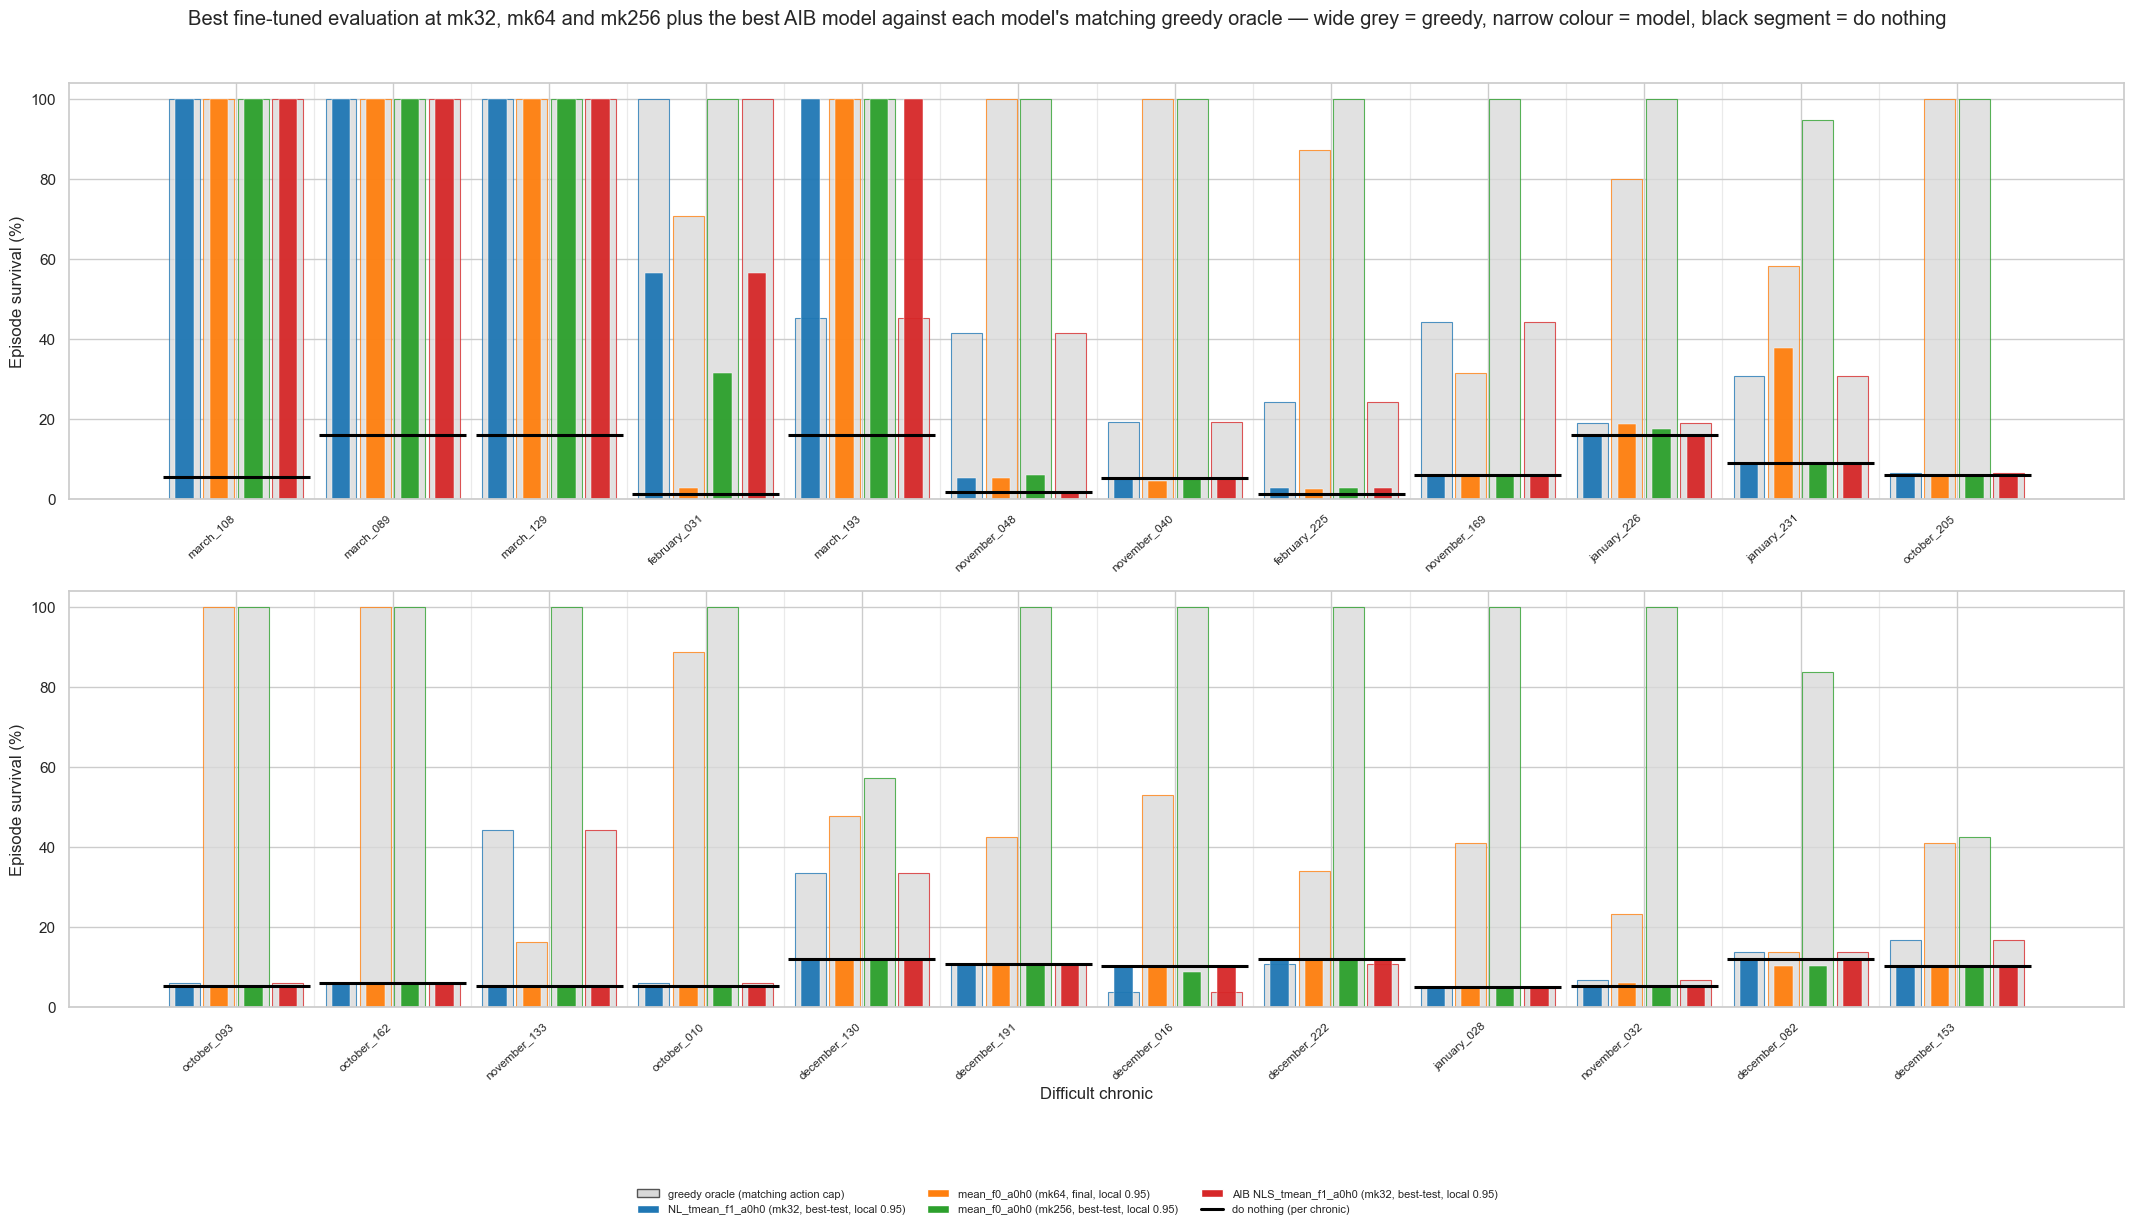

,route,variant,model_label,mk,model_hard_pct,greedy_hard_pct,mean_gap_pp,model_beats_greedy,exact_ties,full_survivals
0,MAPPO fine-tune (conservative),NL_tmean_f1_a0h0,"NL_tmean_f1_a0h0 (mk32, best-test, local 0.95)",32,25.27,33.11,-7.85,6,3,4
1,bus14 zero-shot + AIB,NLS_tmean_f1_a0h0,"AIB NLS_tmean_f1_a0h0 (mk32, best-test, local ...",32,25.12,33.11,-7.99,6,3,4
2,MAPPO fine-tune (conservative),NLS_mean_f0_a0h0,"mean_f0_a0h0 (mk64, final, local 0.95)",64,24.27,67.88,-43.62,0,4,4
3,MAPPO fine-tune (aggressive),NLS_mean_f0_a0h0,"mean_f0_a0h0 (mk256, best-test, local 0.95)",256,24.15,94.92,-70.77,0,4,4


In [20]:
PAIR_CAPS = [32, 64, 256]
pair_candidates = runs.loc[
    runs["route"].astype(str).str.contains("fine-tune")
    & runs["mk"].isin(PAIR_CAPS)
    & runs["hard_pct"].notna()
].copy()
best_pair_indices = pair_candidates.groupby("mk", observed=True)["hard_pct"].idxmax()
best_finetuned_models = pair_candidates.loc[best_pair_indices, [
    "key", "variant", "mk", "hard_pct", "route", "selection",
    "gate", "heuristic", "rho",
]].sort_values("mk").copy()
assert set(best_finetuned_models["mk"].astype(int)) == set(PAIR_CAPS), "a requested action cap has no fine-tuned evaluation"

aib_candidates = runs.loc[
    (runs["route"] == "bus14 zero-shot + AIB") & runs["hard_pct"].notna()
].copy()
aib_candidates["prefer_nls"] = aib_candidates["variant"].str.startswith("NLS_").astype(int)
best_aib_model = (
    aib_candidates.sort_values(
        ["hard_pct", "mk", "prefer_nls"], ascending=[False, True, False]
    ).head(1)[["key", "variant", "mk", "hard_pct", "route",
               "selection", "gate", "heuristic", "rho"]]
)
assert len(best_aib_model) == 1
pair_models = pd.concat([best_finetuned_models, best_aib_model], ignore_index=True)

def best_cap_model_label(row):
    architecture = row["variant"].replace("NLS_", "")
    if row["route"] == "bus14 zero-shot + AIB":
        architecture = "AIB NLS_" + architecture
    selection = "best-test" if row["selection"] == "best test" else "final"
    if row["gate"] == "ungated":
        evaluation = "ungated"
    else:
        scope = "global" if row["heuristic"] == "global rho" else "local"
        evaluation = f"{scope} {row['rho']:.2f}"
    return f"{architecture} (mk{int(row['mk'])}, {selection}, {evaluation})"

pair_models["model_label"] = pair_models.apply(best_cap_model_label, axis=1)
pair_model_order = (
    pair_models.loc[pair_models["route"] != "bus14 zero-shot + AIB"]
    .sort_values("mk")["model_label"].tolist()
    + pair_models.loc[pair_models["route"] == "bus14 zero-shot + AIB", "model_label"].tolist()
)

pair_episodes = (
    data.episodes.loc[data.episodes["key"].isin(pair_models["key"]) & data.episodes["is_hard"]]
    .merge(pair_models[["key", "variant", "mk", "route", "model_label"]],
           on="key", how="inner", validate="many_to_one")
)
greedy_match = (
    data.greedy_episodes.loc[
        data.greedy_episodes["mk"].isin(pair_models["mk"].unique())
        & data.greedy_episodes["is_hard"],
        ["mk", "greedy_chronic_fingerprint", "greedy_survival",
         "greedy_steps", "greedy_nonidle_actions"],
    ]
    .rename(columns={"greedy_chronic_fingerprint": "chronic_fingerprint"})
)
assert not greedy_match.duplicated(["mk", "chronic_fingerprint"]).any()
pair_chronic = pair_episodes.merge(
    greedy_match, on=["mk", "chronic_fingerprint"], how="left", validate="many_to_one"
)
assert pair_chronic["greedy_survival"].notna().all(), "a matching greedy chronic is missing"
assert len(pair_chronic) == N_HARD * len(pair_models)
pair_chronic["model_survival_pct"] = 100 * pair_chronic["survival"]
pair_chronic["greedy_survival_pct"] = 100 * pair_chronic["greedy_survival"]
pair_chronic["gap_to_greedy_pp"] = (
    pair_chronic["model_survival_pct"] - pair_chronic["greedy_survival_pct"]
)

chronic_order = (
    pair_chronic.groupby("chronic_name", observed=True)["greedy_survival_pct"].mean()
    .sort_values(ascending=False).index.tolist()
)
model_colors = dict(zip(pair_model_order, sns.color_palette("tab10", len(pair_model_order))))
slot = 0.88 / len(pair_model_order)
wide_width = slot * 0.90
narrow_width = slot * 0.54
offsets = (np.arange(len(pair_model_order)) - (len(pair_model_order) - 1) / 2) * slot

chronic_panels = [chronic_order[start:start + 12] for start in range(0, len(chronic_order), 12)]
fig, axes = plt.subplots(len(chronic_panels), 1, figsize=(21.5, 6.2 * len(chronic_panels)),
                         sharey=True, squeeze=False)
axes = axes.ravel()
for ax, panel_chronics in zip(axes, chronic_panels):
    centres = np.arange(len(panel_chronics), dtype=float)
    for model_index, model_label in enumerate(pair_model_order):
        model_rows = (
            pair_chronic.loc[pair_chronic["model_label"] == model_label]
            .set_index("chronic_name").reindex(panel_chronics)
        )
        x = centres + offsets[model_index]
        # Matching greedy oracle behind the model: same chronic and same action cap.
        ax.bar(x, model_rows["greedy_survival_pct"], width=wide_width,
               color="#D9D9D9", edgecolor=model_colors[model_label], linewidth=0.8,
               alpha=0.78, zorder=1)
        ax.bar(x, model_rows["model_survival_pct"], width=narrow_width,
               color=model_colors[model_label], edgecolor="white", linewidth=0.35,
               alpha=0.95, zorder=2)
    do_nothing_rows = (
        pair_chronic.drop_duplicates("chronic_name").set_index("chronic_name")
        .reindex(panel_chronics)
    )
    for centre, do_nothing_survival in zip(centres, 100 * do_nothing_rows["dn_survival"]):
        ax.hlines(do_nothing_survival, centre - 0.47, centre + 0.47,
                  color="black", linewidth=2.2, zorder=4)
    for boundary in centres[:-1] + 0.5:
        ax.axvline(boundary, color="#EAEAEA", linewidth=0.9, zorder=0)
    ax.set_xticks(centres, [name.replace("Scenario_", "") for name in panel_chronics],
                  rotation=42, ha="right", fontsize=8.5)
    ax.set_ylim(0, 104)
    ax.set_ylabel("Episode survival (%)")
axes[-1].set_xlabel("Difficult chronic")
fig.suptitle(
    f"Best fine-tuned evaluation at mk32, mk64 and mk256 plus the best AIB model "
    f"against each model's matching greedy oracle "
    f"— wide grey = greedy, narrow colour = model, black segment = do nothing",
    y=0.995,
)
from matplotlib.lines import Line2D
legend_handles = [Patch(facecolor="#D9D9D9", edgecolor="#555555",
                        label="greedy oracle (matching action cap)")]
legend_handles += [Patch(facecolor=model_colors[label], label=label) for label in pair_model_order]
legend_handles += [Line2D([0], [0], color="black", linewidth=2.2, label="do nothing (per chronic)")]
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 0.015),
           ncol=3, fontsize=8, frameon=False)
fig.tight_layout(rect=(0, 0.10, 1, 0.98))
save_figure(fig, "14_best_ft_caps_plus_aib_hard_chronic_vs_greedy")
plt.show()

pair_chronic_summary = (
    pair_chronic.groupby(["route", "variant", "model_label", "mk"], observed=True)
    .agg(model_hard_pct=("model_survival_pct", "mean"),
         greedy_hard_pct=("greedy_survival_pct", "mean"),
         mean_gap_pp=("gap_to_greedy_pp", "mean"),
         model_beats_greedy=("gap_to_greedy_pp", lambda values: int((values > 1e-9).sum())),
         exact_ties=("gap_to_greedy_pp", lambda values: int(np.isclose(values, 0).sum())),
         full_survivals=("full_survival", "sum"))
    .sort_values("model_hard_pct", ascending=False).reset_index()
)
display(pair_chronic_summary.round(2))


## 13. The same matrix for the adaptive intervention budget

Sections 1–4 read the plain `cas_hl` zero-shot grid. The AIB arm is the same
shared-candidate actor trained on bus14 with the **adaptive intervention budget**
active — a Lagrangian on the local-safe cost, targeting a 10 % intervention rate
(`d010`) — then transferred to WCCI zero-shot exactly as before.

It is a separate route in the loader (`bus14 zero-shot + AIB`) rather than part of
the §1–§4 factorial, because it is a different training recipe. It was evaluated
at four caps in both gate conditions, so the matrix below is the §4 heat map
drawn twice: once ungated, once with the local-rho gate at 0.95.

The question this answers is the one AIB was designed for. The gate is a
hand-tuned threshold applied at deployment; AIB is a timing rule *learned during
training*, so it travels inside the weights. If AIB works, its ungated column
should look like somebody else's gated column.

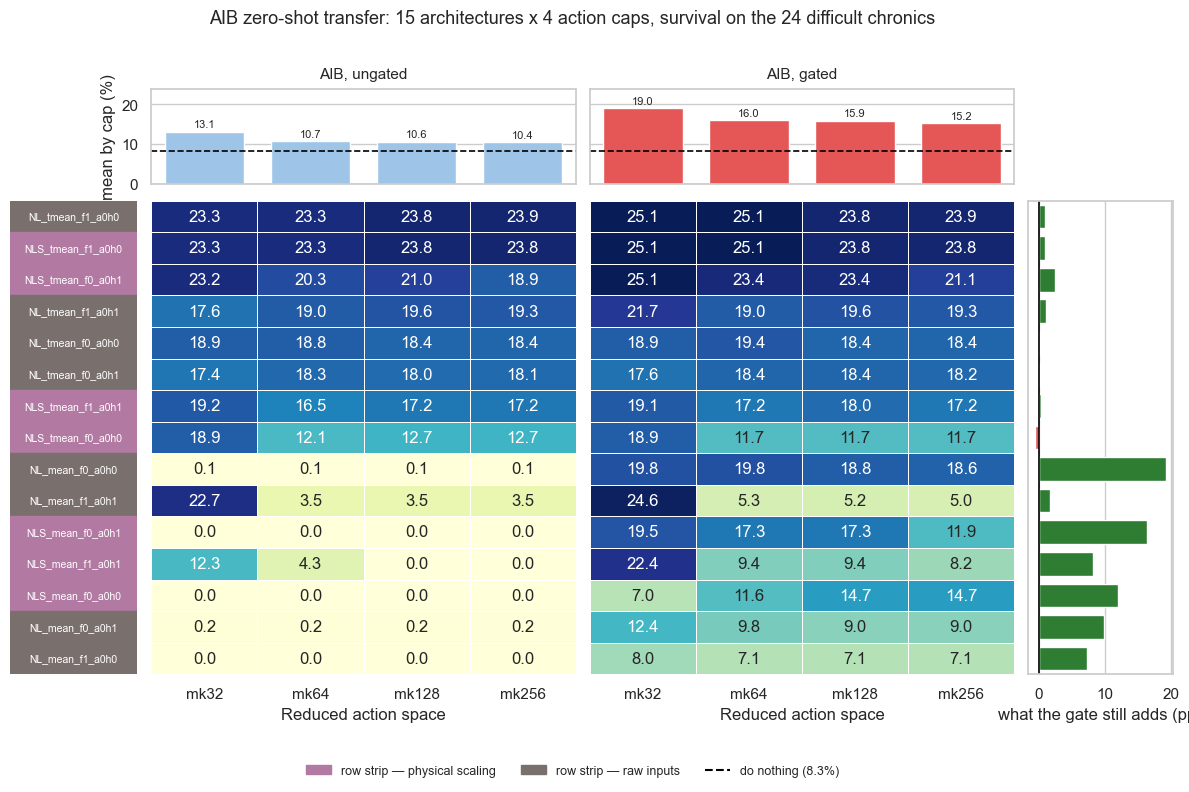

_15 of 16 architectures: `NLS_mean_f1_a0h0` has no AIB checkpoint._

#### Paired contrasts, matched on architecture x cap

,contrast,gate,cells,mean_pp,ci_low,ci_high,wins
0,AIB - plain zero-shot,ungated,60,0.23,-2.32,2.78,25
1,AIB - plain zero-shot,gated,60,-0.60,-2.56,1.35,29
2,gate on bus14 zero-shot,ungated -> gated,64,6.17,4.79,7.55,57
3,gate on bus14 zero-shot + AIB,ungated -> gated,60,5.33,3.74,6.99,53


In [21]:
AIB_CAPS = W.caps_in(runs.loc[runs["route"] == "bus14 zero-shot + AIB"])
aib = runs.loc[runs["route"] == "bus14 zero-shot + AIB"]
AIB_HARD = {
    gate: aib.loc[aib["gate"] == gate].pivot_table(index="variant", columns="mk", values="hard_pct")
    for gate in ("ungated", "gated")
}
# One row order for both panels so the pair can be read across.
AIB_ORDER = (
    pd.concat(AIB_HARD.values()).groupby(level=0).mean()
    .mean(axis=1).sort_values(ascending=False).index.tolist()
)
AIB_HARD = {g: m.reindex(AIB_ORDER) for g, m in AIB_HARD.items()}
vmax = max(m.to_numpy().max() for m in AIB_HARD.values())

fig = plt.figure(figsize=(15.0, 7.6))
gs = fig.add_gridspec(2, 4, width_ratios=[0.30, 1, 1, 0.34], height_ratios=[0.20, 1],
                      wspace=0.05, hspace=0.06)
ax_strip = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 3])
panels = {}
for col, gate in enumerate(("ungated", "gated"), start=1):
    ax_main = fig.add_subplot(gs[1, col])
    ax_top = fig.add_subplot(gs[0, col])
    matrix = AIB_HARD[gate]
    sns.heatmap(matrix, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.7,
                linecolor="white", cbar=False, ax=ax_main, vmin=0, vmax=vmax)
    ax_main.set(xlabel="Reduced action space", ylabel="")
    ax_main.set_xticklabels([f"mk{c}" for c in AIB_CAPS])
    ax_main.set_yticklabels([])
    ax_top.bar(np.arange(len(AIB_CAPS)) + 0.5, matrix.mean(), width=0.75,
               color=W.GATE_COLORS[gate], edgecolor="white", linewidth=1.0)
    for x, value in enumerate(matrix.mean()):
        ax_top.annotate(f"{value:.1f}", (x + 0.5, value), xytext=(0, 3),
                        textcoords="offset points", ha="center", fontsize=8)
    ax_top.axhline(DN_HARD, color="black", linestyle="--", linewidth=1.2)
    ax_top.set(xlim=(0, len(AIB_CAPS)), xticks=[], ylim=(0, vmax * 0.95))
    ax_top.set_title(f"AIB, {gate}", fontsize=11, pad=8)
    if col == 1:
        ax_top.set_ylabel("mean by cap (%)")
    else:
        ax_top.set_yticklabels([])
    panels[gate] = ax_main

for y, variant in enumerate(AIB_ORDER):
    family = "NLS" if variant.startswith("NLS") else "NL"
    ax_strip.add_patch(plt.Rectangle((0, y), 1, 1, color=SCALE_COLORS[family]))
    ax_strip.text(0.5, y + 0.5, variant, ha="center", va="center", fontsize=7.5, color="white")
ax_strip.set(xlim=(0, 1), ylim=(len(AIB_ORDER), 0), xticks=[], yticks=[])
ax_strip.grid(False)
for spine in ax_strip.spines.values():
    spine.set_visible(False)

gate_gain = (AIB_HARD["gated"].mean(axis=1) - AIB_HARD["ungated"].mean(axis=1)).reindex(AIB_ORDER)
ax_right.barh(np.arange(len(AIB_ORDER)) + 0.5, gate_gain,
              color=["#2E7D32" if v > 0 else "#E45756" for v in gate_gain],
              edgecolor="white", linewidth=1.0, height=0.75)
ax_right.axvline(0, color="black", linewidth=1.2)
ax_right.set(ylim=(len(AIB_ORDER), 0), yticks=[], xlabel="what the gate still adds (pp)")

fig.legend(
    handles=[Patch(color=c, label=f"row strip — {W.SCALING_LABELS[k]}") for k, c in SCALE_COLORS.items()]
    + [plt.Line2D([], [], color="black", linestyle="--", label=f"do nothing ({DN_HARD:.1f}%)")],
    loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.04), frameon=False)
fig.suptitle(
    f"AIB zero-shot transfer: {len(AIB_ORDER)} architectures x {len(AIB_CAPS)} action caps, "
    f"survival on the {N_HARD} difficult chronics",
    y=0.985, fontsize=13,
)
save_figure(fig, "13_aib_matrix")
plt.show()

missing = sorted(set(runs.loc[runs["route"] == "bus14 zero-shot", "variant"]) - set(AIB_ORDER))
if missing:
    display(Markdown(
        f"_{len(AIB_ORDER)} of 16 architectures: `{'`, `'.join(missing)}` has no AIB checkpoint._"
    ))

both = runs.loc[runs["route"].isin(["bus14 zero-shot", "bus14 zero-shot + AIB"])
                & runs["mk"].isin(AIB_CAPS)]
rows = []
for gate in ("ungated", "gated"):
    pairs = W.matched_pairs(both.loc[both["gate"] == gate], "route",
                            ("bus14 zero-shot", "bus14 zero-shot + AIB"), ["variant", "mk"])
    mean_d, lo, hi = W.paired_bootstrap(pairs["delta"])
    rows.append({"contrast": "AIB - plain zero-shot", "gate": gate, "cells": len(pairs),
                 "mean_pp": mean_d, "ci_low": lo, "ci_high": hi,
                 "wins": int((pairs["delta"] > 0).sum())})
for route in ("bus14 zero-shot", "bus14 zero-shot + AIB"):
    subset = runs.loc[(runs["route"] == route) & runs["mk"].isin(AIB_CAPS)]
    pairs = W.matched_pairs(subset, "gate", ("ungated", "gated"), ["variant", "mk"])
    mean_d, lo, hi = W.paired_bootstrap(pairs["delta"])
    rows.append({"contrast": f"gate on {route}", "gate": "ungated -> gated", "cells": len(pairs),
                 "mean_pp": mean_d, "ci_low": lo, "ci_high": hi,
                 "wins": int((pairs["delta"] > 0).sum())})
aib_contrasts = pd.DataFrame(rows)
display(Markdown("#### Paired contrasts, matched on architecture x cap"))
display(aib_contrasts)

In [22]:
exports = {
    "grid_hard_pct.csv": HARD.reset_index(),
    "grid_capture_pct.csv": CAPTURE.reset_index(),
    "action_space_paired.csv": stats,
    "scaling_pairs.csv": pairs,
    "architecture_ranking.csv": ranking.sort_values("hard_mean", ascending=False),
    "coverage.csv": cover_ungated.reset_index(),
    "transfer_vs_scratch.csv": best64[["variant", "gate", "route", "run", "overall_pct",
                                       "checkpoint_step"]],
    "gain_over_scratch.csv": summary,
    "ft32_runs.csv": ft32[["variant", "selection", "gate", "rho", "run",
                                  "checkpoint_step", "overall_pct", "hard_pct",
                                  "hard_rescues", "hard_wins", "hard_losses",
                                  "easy_kept", "policy_nonidle_per_1k",
                                  "executed_nonidle_per_1k",
                                  "blocked_policy_nonidle_pct"]],
    "ft32_action_summary.csv": action_summary32,
    "ft32_gate_deltas.csv": gate_delta32,
    "ft32_vs_zero_shot.csv": zero_vs_ft32,
    "all_finetuned_hard_matrix.csv": ft_hard_matrix.reset_index(),
    "all_finetuned_complete_ranking.csv": ft_complete_ranking.reset_index(),
    "best_finetuned_caps_plus_aib_hard_chronic_vs_greedy.csv": pair_chronic[["chronic_name",
        "chronic_fingerprint", "route", "variant", "model_label", "mk",
        "model_survival_pct", "greedy_survival_pct", "gap_to_greedy_pp",
        "greedy_nonidle_actions"]],
    "best_finetuned_caps_plus_aib_hard_chronic_vs_greedy_summary.csv": pair_chronic_summary,
}
for name, table in exports.items():
    table.to_csv(EXPORT_DIR / name, index=False)
print(f"{len(exports)} tables + notebook figures written to:\n{EXPORT_DIR}")

16 tables + notebook figures written to:
/Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/transfer_story
